# Recommendation System
In this notebook, we will implement 5 Models

0.   Baseline Methods
1.   Collaborative filtering methods - User-based and Item-Based
2.   Matrix Decomposition -SVD, ALS(not applicable in this case), SVD++
3.   Hybrid recommendations approaches
4.   Extension-Methods in Academic and Industry and potential Implementation


In this notebook, we will also cover how to use numba to optimize our code by get ride of nested loop and repetitive calculation

1.   Numba in Basline Model
2.   Numba in Cosine Similarity


4 metrics

1.   recommendation quality (Precision/Recall/hit rate)
2.   rating accuracy (RMSE)



# Loading Packages and Dataframes

In [1]:
!pip install "numpy<2.0"
!pip install scikit-surprise
!pip install optuna

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554980 sha256=ac23234590d517129601f087b2c1affcccd4d6b91bcc75d58cd0721f1456099c
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.2 MB/s eta 0:00:00


In [2]:
#load packages
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import optuna
from surprise.model_selection import cross_validate
from collections import defaultdict
from surprise import NMF
from numba import njit,prange
import time
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy
from google.colab import files
from surprise import SVDpp
from surprise import accuracy as surprise_accuracy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load our dataset ml-1m
uploaded = files.upload()

Saving movies.dat to movies.dat
Saving ratings.dat to ratings.dat
Saving users.dat to users.dat


In [4]:
movies = pd.read_csv(
    "movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["movieId","title","genres"]
)

print(movies.head())

   movieId                               title                        genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy


In [5]:
ratings = pd.read_csv(
    "ratings.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

print(ratings.head())

   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291


In [6]:
users = pd.read_csv(
    "users.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["user_id", "gender", "age", "occupation", "zip"]
)

print(users.head())

   user_id gender  age  occupation    zip
0        1      F    1          10  48067
1        2      M   56          16  70072
2        3      M   25          15  55117
3        4      M   45           7  02460
4        5      M   25          20  55455


In [7]:
data = pd.merge(ratings, users, on="user_id")
data = pd.merge(data, movies, left_on="movie_id", right_on="movieId")
data.head()


,user_id,movie_id,rating,timestamp,gender,age,occupation,zip,movieId,title,genres
0,1,1193,5,978300760,F,1,10,48067,1193,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,661,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,914,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,3408,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy


# EDA

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 11 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   user_id     1000209 non-null  int64 
 1   movie_id    1000209 non-null  int64 
 2   rating      1000209 non-null  int64 
 3   timestamp   1000209 non-null  int64 
 4   gender      1000209 non-null  object
 5   age         1000209 non-null  int64 
 6   occupation  1000209 non-null  int64 
 7   zip         1000209 non-null  object
 8   movieId     1000209 non-null  int64 
 9   title       1000209 non-null  object
 10  genres      1000209 non-null  object
dtypes: int64(7), object(4)
memory usage: 83.9+ MB


**Ratings behavior and distribution**

<Axes: >

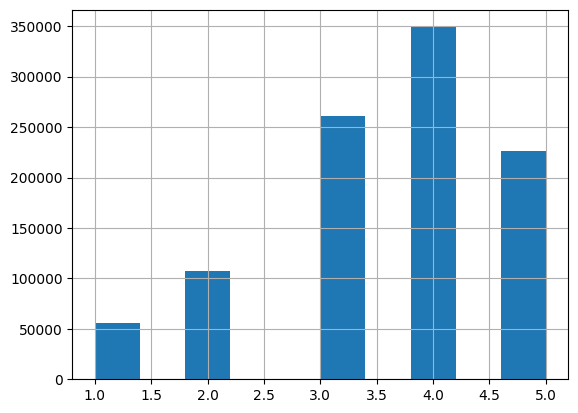

In [ ]:
#visualize ratings distribution
data["rating"].value_counts().sort_index()
data["rating"].hist()

In [ ]:
#movies per users distribution
data.groupby("user_id").size().describe()

,0
count,6040.000000
mean,165.597517
std,192.747029
min,20.000000
25%,44.000000
50%,96.000000
75%,208.000000
max,2314.000000




1.   There are 6,040 users total.
2.   On average, each user rated about 166 movies.
3.   Very high standard deviation: some users rated very few movies, some rated hundreds or thousands
4.   The median is 96 which means that half the users rated 96 or fewer movies.



**movies behavior and distribution**

In [ ]:
distinct_movies=data['movie_id'].nunique()
num_ratings=data.shape[0]
print(f"we have {distinct_movies} distinct movies, and we have in total {num_ratings} ratings, so in average we have {num_ratings//distinct_movies} of ratings per movie")

we have 3706 distinct movies, and we have in total 1000209 ratings, so in average we have 269 of ratings per movie


In [ ]:
data.groupby('movie_id')['rating'].mean().describe()

,rating
count,3706.000000
mean,3.238892
std,0.672925
min,1.000000
25%,2.822705
50%,3.331546
75%,3.740741
max,5.000000



1.   In total we have 3706 movies
2.   Average of all movie-average ratings=3.24
3.   Most of Movies in the range of 3.24±0.67⇒[2.57,3.91]



In [ ]:
movie_stats = data.groupby('movie_id').agg({
    'rating': ['count', 'mean']
})
movie_stats.columns = ['count', 'mean']  # flatten MultiIndex

**user hehavior and distribution**

In [ ]:
data.groupby('user_id')['rating'].mean().describe()

,rating
count,6040.000000
mean,3.702705
std,0.429622
min,1.015385
25%,3.444444
50%,3.735294
75%,4.000000
max,4.962963


In [ ]:
data.groupby('user_id')['rating'].std().describe()

,rating
count,6040.000000
mean,1.010186
std,0.203769
min,0.124035
25%,0.869130
50%,0.997096
75%,1.134735
max,1.861354


**so, we are testing if there is a positive relationship between ratings value and rating amount- we are using is internally a t-test in here.**


H0.  No relationship between popularity and average rating
H1.  there is a relationship between popularity abd averge rating(If corr > 0 → H₁ is that there is a positive correlation. If corr ≤ 0 → H₁ is that there is a negative correlation)



In [ ]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(movie_stats['count'], movie_stats['mean'])

# convert to one-sided p-value
if corr > 0:
    p_value_one_sided = p_value / 2
else:
    p_value_one_sided = 1 - p_value / 2

print(corr, p_value_one_sided)

0.3579560372867075 9.466835861859625e-113


There is a statistically significant but modest positive correlation between how many ratings a movie gets and its average rating. Popular movies (more ratings) do tend to be rated slightly higher, but the effect isn't dramatic — plenty of variance is explained by other factors.

**Behaviors between males and females**

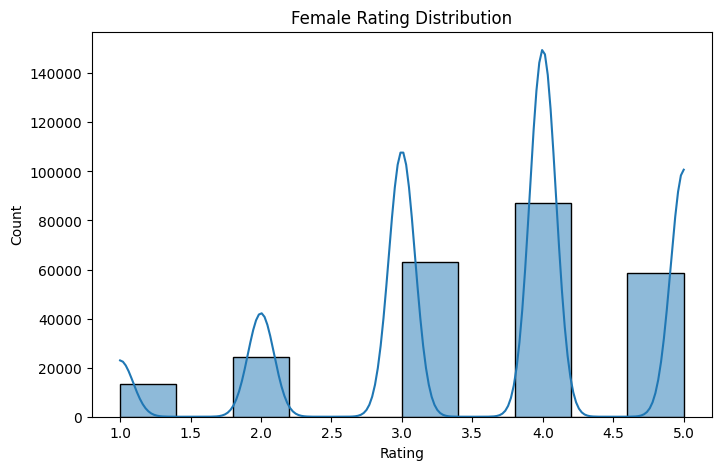

In [ ]:
female_ratings = data[data['gender'] == 'F']['rating']
plt.figure(figsize=(8, 5))
sns.histplot(female_ratings, bins=10, kde=True)
plt.title('Female Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

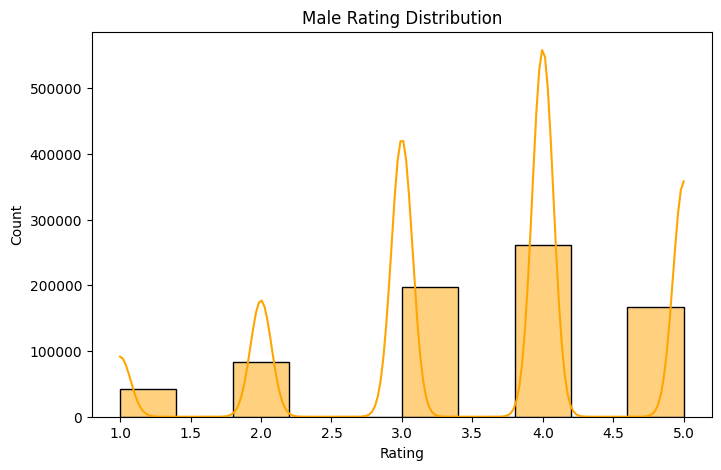

In [ ]:
male_ratings = data[data['gender'] == 'M']['rating']
plt.figure(figsize=(8, 5))
sns.histplot(male_ratings, bins=10, kde=True,color="orange")
plt.title('Male Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [ ]:
data.groupby('gender')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
F,246440.0,3.620366,1.111228,1.0,3.0,4.0,4.0,5.0
M,753769.0,3.568879,1.118724,1.0,3.0,4.0,4.0,5.0


In [ ]:
gender_table=data.pivot_table(index='genres', columns='gender', values='rating', aggfunc='mean')

In [ ]:
gender_table['diff']=abs(gender_table['F']-gender_table['M'])
gender_table.sort_values("diff",ascending=False)

gender,F,M,diff
genres,,,
Comedy|Film-Noir|Thriller,1.000000,2.250000,1.250000
Children's|Drama|Fantasy,3.538462,2.756410,0.782051
Action|Comedy|Romance|Thriller,3.254717,2.578358,0.676359
Crime|Mystery,2.687500,3.360656,0.673156
Action|Adventure|Animation|Children's|Fantasy,3.146341,2.510638,0.635703
...,...,...,...
Mystery|Sci-Fi|Thriller,3.489474,3.493797,0.004323
Action|War,3.000000,3.003206,0.003206
Fantasy|Sci-Fi,3.354331,3.356495,0.002165


In [ ]:
# add counts
gender_table['F_count'] = data[data['gender'] == 'F'].groupby('genres')['rating'].count()
gender_table['M_count'] = data[data['gender'] == 'M'].groupby('genres')['rating'].count()
gender_table.sort_values("diff",ascending=False)

gender,F,M,diff,F_count,M_count
genres,,,,,
Comedy|Film-Noir|Thriller,1.000000,2.250000,1.250000,1.0,4
Children's|Drama|Fantasy,3.538462,2.756410,0.782051,52.0,78
Action|Comedy|Romance|Thriller,3.254717,2.578358,0.676359,106.0,268
Crime|Mystery,2.687500,3.360656,0.673156,16.0,61
Action|Adventure|Animation|Children's|Fantasy,3.146341,2.510638,0.635703,41.0,94
...,...,...,...,...,...
Mystery|Sci-Fi|Thriller,3.489474,3.493797,0.004323,190.0,806
Action|War,3.000000,3.003206,0.003206,314.0,3119
Fantasy|Sci-Fi,3.354331,3.356495,0.002165,127.0,662


In [ ]:
min_ratings = 50
filtered = gender_table[
    (gender_table['F_count'] >= min_ratings) &
    (gender_table['M_count'] >= min_ratings)
].sort_values('diff', ascending=False)

filtered=filtered.head(20)
filtered

gender,F,M,diff,F_count,M_count
genres,,,,,
Children's|Drama|Fantasy,3.538462,2.756410,0.782051,52.0,78
Action|Comedy|Romance|Thriller,3.254717,2.578358,0.676359,106.0,268
Action|Adventure|Comedy|Horror,3.297297,3.909283,0.611985,74.0,474
Action|Western,3.541667,4.144167,0.602500,144.0,1200
Children's|Musical,3.859504,3.286325,0.573179,121.0,234
Children's|Comedy|Mystery,3.325301,2.805970,0.519331,83.0,134
Comedy|Horror|Musical|Sci-Fi,3.673016,3.160131,0.512885,315.0,918
Action|Comedy|Crime|Horror|Thriller,2.735714,3.232558,0.496844,140.0,774
Adventure|Children's|Comedy,3.046083,2.567901,0.478182,217.0,567


In [ ]:
from scipy.stats import ttest_ind

results = []
for genre in filtered.index:
    f_ratings = data[(data['genres'] == genre) & (data['gender'] == 'F')]['rating']
    m_ratings = data[(data['genres'] == genre) & (data['gender'] == 'M')]['rating']
    t, p = ttest_ind(f_ratings, m_ratings)
    results.append({'genre': genre, 'diff': f_ratings.mean() - m_ratings.mean(), 'p_value': p})

results_df = pd.DataFrame(results).sort_values('p_value')
results_df[results_df['p_value'] < 0.05]

,genre,diff,p_value
19,Musical|Romance,0.343613,4.298043e-20
3,Action|Western,-0.602500,1.654910e-15
11,Comedy|Musical|Romance,0.409492,1.718079e-13
17,Adventure|Children's,0.350151,6.860929e-13
12,Action|Sci-Fi|Thriller|War,-0.384601,7.341277e-11
6,Comedy|Horror|Musical|Sci-Fi,0.512885,3.408140e-10
8,Adventure|Children's|Comedy,0.478182,6.334674e-08
1,Action|Comedy|Romance|Thriller,0.676359,2.320189e-07
4,Children's|Musical,0.573179,3.166007e-06
7,Action|Comedy|Crime|Horror|Thriller,-0.496844,3.981458e-06


In [ ]:
results_df=results_df[results_df['p_value'] < 0.01]
results_df

,genre,diff,p_value
19,Musical|Romance,0.343613,4.298043e-20
3,Action|Western,-0.602500,1.654910e-15
11,Comedy|Musical|Romance,0.409492,1.718079e-13
17,Adventure|Children's,0.350151,6.860929e-13
12,Action|Sci-Fi|Thriller|War,-0.384601,7.341277e-11
6,Comedy|Horror|Musical|Sci-Fi,0.512885,3.408140e-10
8,Adventure|Children's|Comedy,0.478182,6.334674e-08
1,Action|Comedy|Romance|Thriller,0.676359,2.320189e-07
4,Children's|Musical,0.573179,3.166007e-06
7,Action|Comedy|Crime|Horror|Thriller,-0.496844,3.981458e-06


Positive diff → Women rated higher than men

Negative diff → Men rated higher than women

**Summary**

H0.There is no difference between male and female ratings for a given genre

H1.There is a statistically significant difference between male and female ratings for a given genre

Test Used: Independent samples t-test (ttest_ind) Applied to each genre, comparing male vs female ratings.

17 genres showed a statistically significant difference (p < 0.01). We reject H₀ for 27 genres — meaning in these genres, male and female users rate statistically differently

Positive diff = females rated higher, negative diff = males rated higher

The most significant differences (smallest p-values) were in Musical|Romance, Action|Western, and Comedy|Musical|Romance



# Grenre Graphs

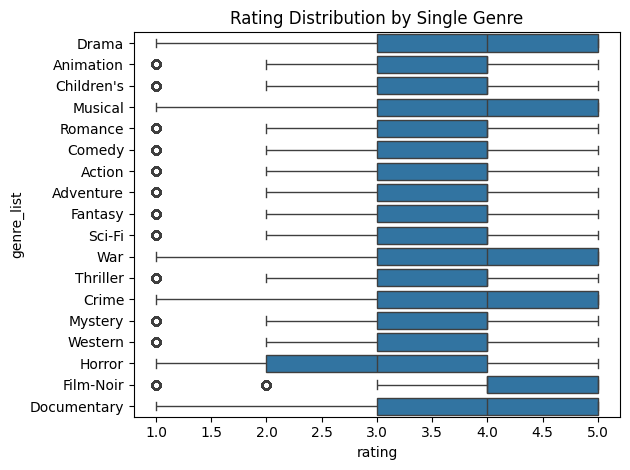

In [ ]:
data['genre_list'] = data['genres'].str.split('|')
data_exploded = data.explode('genre_list')

sns.boxplot(data=data_exploded, y='genre_list', x='rating')
plt.title('Rating Distribution by Single Genre')
plt.tight_layout()
plt.show()

Horror stands out — its box starts at 2, meaning 25% of ratings are below 2. It has the lowest Q1 of all genres, suggesting it receives more low ratings than others.

Drama, War, Crime, Documentary, Musical — their boxes extend to 5 with no upper outliers, meaning high ratings are common and expected.

Film-Noir — has outliers on both ends (1 and 2), suggesting it's a polarizing genre where people either love it or rate it very low.

Most genres look very similar — the medians are all around 3-4, meaning genre alone doesn't drastically change the central rating. The differences we found earlier with the t-test are real but subtle.

**Occupation Analysis**

In [ ]:
occupation_map = {
    0: 'other',
    1: 'academic/educator',
    2: 'artist',
    3: 'clerical/admin',
    4: 'college/grad student',
    5: 'customer service',
    6: 'doctor/health care',
    7: 'executive/managerial',
    8: 'farmer',
    9: 'homemaker',
    10: 'K-12 student',
    11: 'lawyer',
    12: 'programmer',
    13: 'retired',
    14: 'sales/marketing',
    15: 'scientist',
    16: 'self-employed',
    17: 'technician/engineer',
    18: 'tradesman/craftsman',
    19: 'unemployed',
    20: 'writer'
}

data=data.rename(columns={"occupation":"occupation_id"})
# map directly without renaming
data['occupation'] = data['occupation_id'].map(occupation_map)

In [ ]:
data


,user_id,movie_id,rating,timestamp,gender,age,occupation_id,zip,movieId,title,genres,genre_list,occupation
0,1,1193,5,978300760,F,1,10,48067,1193,One Flew Over the Cuckoo's Nest (1975),Drama,[Drama],K-12 student
1,1,661,3,978302109,F,1,10,48067,661,James and the Giant Peach (1996),Animation|Children's|Musical,"[Animation, Children's, Musical]",K-12 student
2,1,914,3,978301968,F,1,10,48067,914,My Fair Lady (1964),Musical|Romance,"[Musical, Romance]",K-12 student
3,1,3408,4,978300275,F,1,10,48067,3408,Erin Brockovich (2000),Drama,[Drama],K-12 student
4,1,2355,5,978824291,F,1,10,48067,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,"[Animation, Children's, Comedy]",K-12 student
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000204,6040,1091,1,956716541,M,25,6,11106,1091,Weekend at Bernie's (1989),Comedy,[Comedy],doctor/health care
1000205,6040,1094,5,956704887,M,25,6,11106,1094,"Crying Game, The (1992)",Drama|Romance|War,"[Drama, Romance, War]",doctor/health care
1000206,6040,562,5,956704746,M,25,6,11106,562,Welcome to the Dollhouse (1995),Comedy|Drama,"[Comedy, Drama]",doctor/health care
1000207,6040,1096,4,956715648,M,25,6,11106,1096,Sophie's Choice (1982),Drama,[Drama],doctor/health care


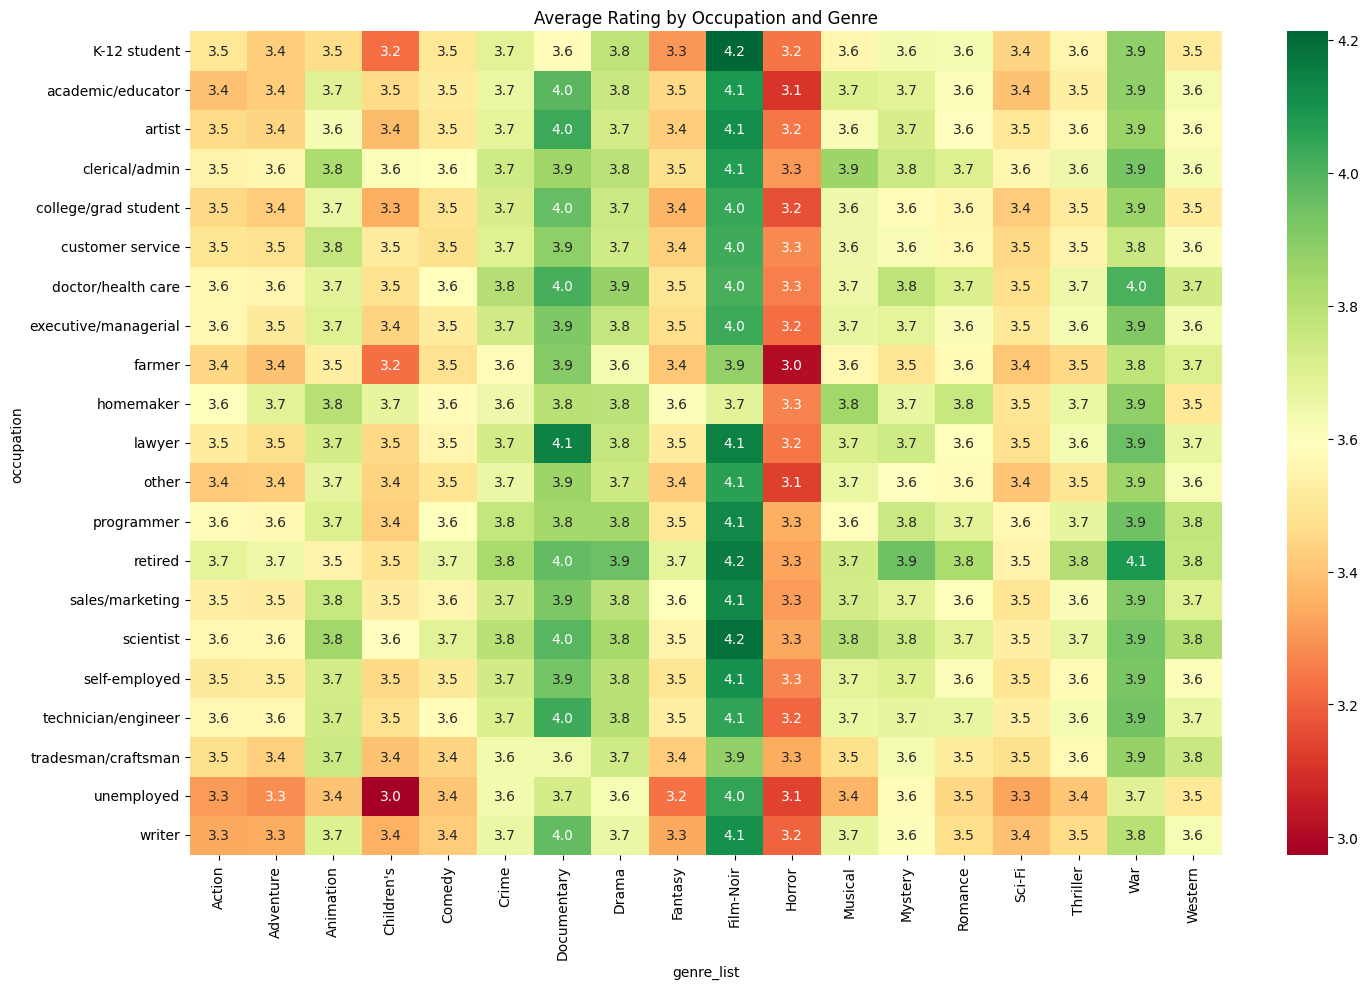

In [ ]:
data['genre_list'] = data['genres'].str.split('|')
data_exploded = data.explode('genre_list')
occ_genre = data_exploded.groupby(['occupation', 'genre_list'])['rating'].mean().unstack()

plt.figure(figsize=(15, 10))
sns.heatmap(occ_genre, annot=True, fmt='.1f', cmap='RdYlGn')
plt.title('Average Rating by Occupation and Genre')
plt.tight_layout()
plt.show()


**Age Analysis**

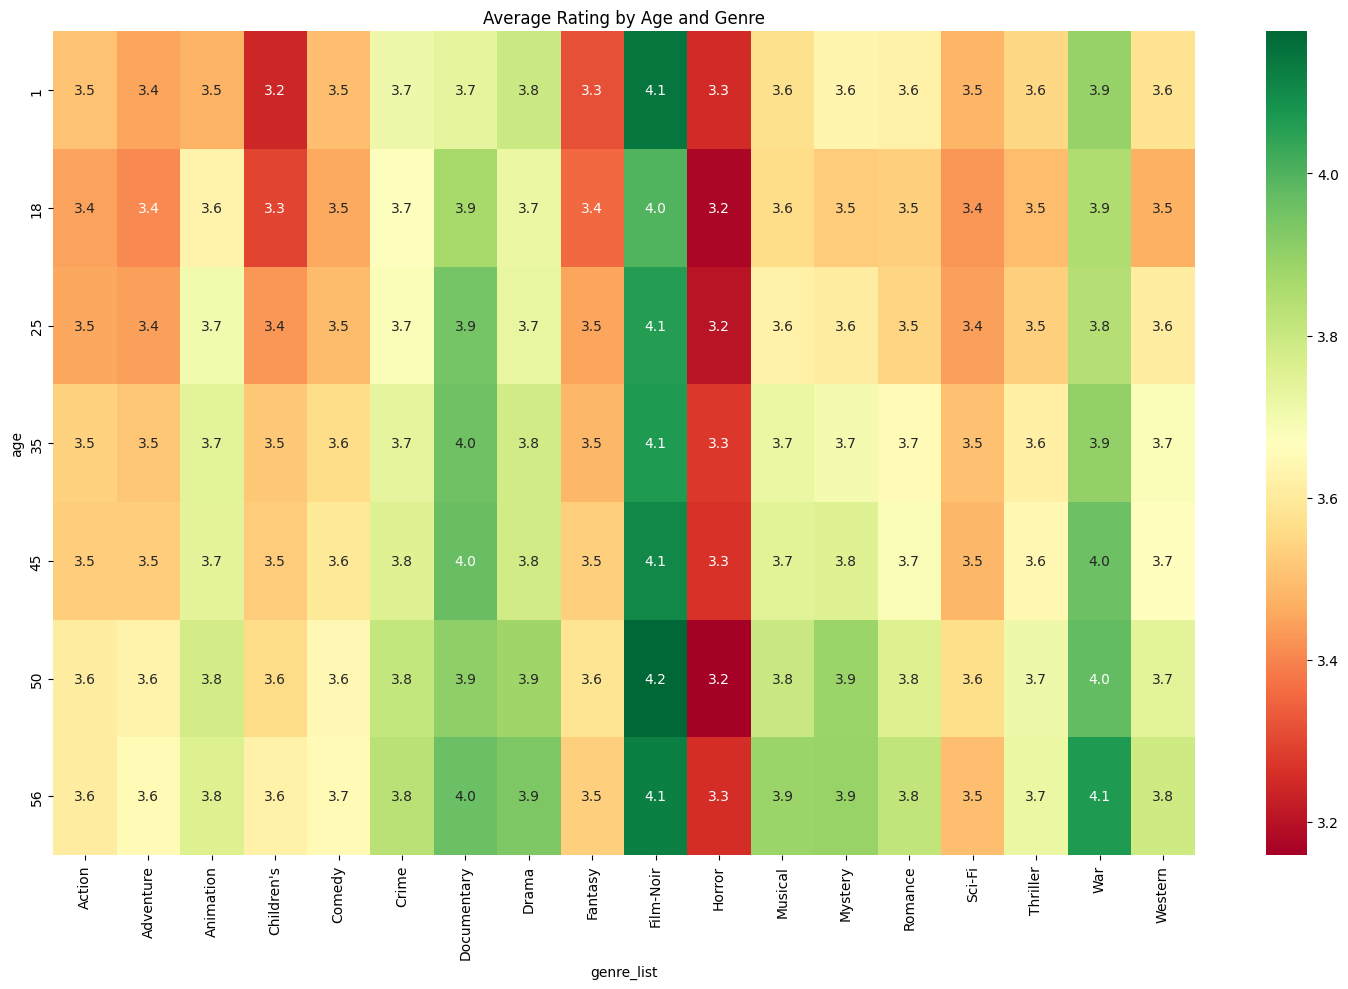

In [ ]:
data['genre_list'] = data['genres'].str.split('|')
data_exploded = data.explode('genre_list')
occ_genre = data_exploded.groupby(['age', 'genre_list'])['rating'].mean().unstack()
occ_genre

plt.figure(figsize=(15, 10))
sns.heatmap(occ_genre, annot=True, fmt='.1f', cmap='RdYlGn')
plt.title('Average Rating by Age and Genre')
plt.tight_layout()
plt.show()

# Baseline Model 1-Popularity Based Recommendation

**reorganize the dataset we are going to use in our diferent models**

In [ ]:
df=data[['user_id','movie_id','rating',"title"]]
df

,user_id,movie_id,rating,title
0,1,1193,5,One Flew Over the Cuckoo's Nest (1975)
1,1,661,3,James and the Giant Peach (1996)
2,1,914,3,My Fair Lady (1964)
3,1,3408,4,Erin Brockovich (2000)
4,1,2355,5,"Bug's Life, A (1998)"
...,...,...,...,...
1000204,6040,1091,1,Weekend at Bernie's (1989)
1000205,6040,1094,5,"Crying Game, The (1992)"
1000206,6040,562,5,Welcome to the Dollhouse (1995)
1000207,6040,1096,4,Sophie's Choice (1982)


In [ ]:
#reorganize popularity matrix
popularity = df.groupby('movie_id').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Most popular = most rated
popular_movies = popularity.sort_values('num_ratings', ascending=False)
popular_movies = popular_movies.merge(df[['movie_id','title']].drop_duplicates(), on='movie_id')

popular_movies.head(10)

,movie_id,num_ratings,avg_rating,title
0,2858,3428,4.317386,American Beauty (1999)
1,260,2991,4.453694,Star Wars: Episode IV - A New Hope (1977)
2,1196,2990,4.292977,Star Wars: Episode V - The Empire Strikes Back...
3,1210,2883,4.022893,Star Wars: Episode VI - Return of the Jedi (1983)
4,480,2672,3.763847,Jurassic Park (1993)
5,2028,2653,4.337354,Saving Private Ryan (1998)
6,589,2649,4.058513,Terminator 2: Judgment Day (1991)
7,2571,2590,4.315830,"Matrix, The (1999)"
8,1270,2583,3.990321,Back to the Future (1985)
9,593,2578,4.351823,"Silence of the Lambs, The (1991)"


In [ ]:
"""
Popularity-Based Recommendation Baseline Evaluator
====================================================
Evaluates a non-personalized popularity-based recommender system
that recommends the same top-K most popular movies to every user.
Used as a baseline to benchmark against more advanced models.

Parameters
----------
df : pd.DataFrame
    Full dataset containing columns: ['user_id', 'movie_id', 'rating']
K : int, default=10
    Number of top popular movies to recommend to each user.

Model
-----
Type        : Non-personalized popularity baseline
Strategy    : Recommend the K most frequently rated movies in the training set
              to every user, regardless of their personal preferences.
Assumption  : Globally popular movies are likely to appeal to any user.

Train/Test Split
----------------
Train : 80% of df — used to compute movie popularity rankings
Test  : 20% of df — used as ground truth for evaluation
Seed  : random_state=42 for reproducibility

Note: Popularity is computed from training data only to prevent data leakage.

Performance Metrics
-------------------
Hit Rate @ K   : Fraction of users for whom at least one recommended movie
                 appears in their test set. Measures basic recommendation coverage.
                 Formula: mean(1 if |watched ∩ top_k| > 0 else 0)

Precision @ K  : Average fraction of recommended movies that the user actually watched.
                 Measures recommendation accuracy.
                 Formula: mean(|watched ∩ top_k| / K)

Recall @ K     : Average fraction of the user's watched movies that were recommended.
                 Measures how much of user interest the model captures.
                 Formula: mean(|watched ∩ top_k| / |watched|)

Output
------
Prints a summary report of Hit Rate, Precision@K, Recall@K, and runtime.
"""

K = 10

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

top_k_movies = (
    train_df.groupby('movie_id')['rating']
    .count()
    .sort_values(ascending=False)
    .head(K)
    .index.tolist()
)

user_test_movies = test_df.groupby('user_id')['movie_id'].apply(set)

top_k_set = set(top_k_movies)

metrics = []
for user_id, watched in user_test_movies.items():
    hits = len(watched & top_k_set)
    metrics.append({
        'user_id'    : user_id,
        'hit'        : int(hits > 0),           # Hit Rate
        'precision'  : hits / K,                 # Precision@K
        'recall'     : hits / len(watched),      # Recall@K
    })

metrics_df = pd.DataFrame(metrics)
end_v1_avg = time.perf_counter()

print("=" * 50)
print(f"Evaluation @ K={K}")
print(f"  Hit Rate:   {metrics_df['hit'].mean():.4f}")
print(f"  Precision:  {metrics_df['precision'].mean():.4f}")
print(f"  Recall:     {metrics_df['recall'].mean():.4f}")

Evaluation @ K=10
  Hit Rate:   0.5653
  Precision:  0.0934
  Recall:     0.0449


# Baseline Model with Numba


In [ ]:
K = 10

#counting runtime
start_v1_pop = time.perf_counter()
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

top_k_movies = (
    train_df.groupby('movie_id')['rating']
    .count()
    .sort_values(ascending=False)
    .head(K)
    .index.tolist()
)

user_test_movies = test_df.groupby('user_id')['movie_id'].apply(set)

top_k_set = set(top_k_movies)

metrics = []
for user_id, watched in user_test_movies.items():
    hits = len(watched & top_k_set)
    metrics.append({
        'user_id'    : user_id,
        'hit'        : int(hits > 0),           # Hit Rate
        'precision'  : hits / K,                 # Precision@K
        'recall'     : hits / len(watched),      # Recall@K
    })

metrics_df = pd.DataFrame(metrics)
end_v1_pop = time.perf_counter()

print("=" * 50)
print(f"Evaluation @ K={K}")
print(f"  Hit Rate:   {metrics_df['hit'].mean():.4f}")
print(f"  Precision:  {metrics_df['precision'].mean():.4f}")
print(f"  Recall:     {metrics_df['recall'].mean():.4f}")
print(f"\n  ⏱ Runtime: {end_v1_pop - start_v1_pop:.4f} sec")

Evaluation @ K=10
  Hit Rate:   0.5653
  Precision:  0.0934
  Recall:     0.0449

  ⏱ Runtime: 0.0962 sec


In [ ]:
"""
Popularity-Based Recommendation Baseline Evaluator — V2 (Numba-Optimized)
==========================================================================
Optimized version of the popularity-based recommender evaluator using
Numba JIT compilation for performance-critical loops. Designed to scale
to large datasets (100k–1M+ users) with minimal memory overhead.

Compared to V1 (pandas groupby-based), V2 replaces Python-level aggregation
with single-pass Numba kernels, eliminating intermediate array allocations.

Parameters
----------
df : pd.DataFrame
    Full dataset containing columns: ['user_id', 'movie_id', 'rating']
K : int, default=10
    Number of top popular movies to recommend to each user.

Model
-----
Type        : Non-personalized popularity baseline
Strategy    : Recommend the K most frequently rated movies in the training set
              to every user, regardless of their personal preferences.
Assumption  : Globally popular movies are likely to appeal to any user.

Train/Test Split
----------------
Train : 80% of df — used to compute movie popularity rankings
Test  : 20% of df — used as ground truth for evaluation
Seed  : random_state=42 for reproducibility

Note: Popularity is computed from training data only to prevent data leakage.

Optimization Strategy
---------------------
Step 1 — train_test_split  : No Numba. sklearn internals are already C-optimized.
Step 2 — Popularity ranking : No Numba. pandas groupby operates at C-level.
Step 3 — isin() flagging    : No Numba. pandas isin() is already vectorized C-level.
Step 4 — compute_user_hits  : Numba JIT. Single-pass loop over sorted user_id array
                               replaces groupby().agg(). Worth it at 100k+ users.
Step 5 — compute_metrics    : Numba JIT. Computes all 3 metrics in one pass with
                               no intermediate arrays. Worth it at 1M+ users.

Numba Functions
---------------
compute_user_hits(user_ids, in_top_k)
    Precondition : user_ids must be sorted ascending.
    Input        : user_ids  (np.ndarray[int]) — sorted user ID array
                   in_top_k  (np.ndarray[int32]) — 1 if movie in top-K, else 0
    Output       : (users, hits, totals) — per-user aggregated arrays
    Complexity   : O(n) time, O(n) space

compute_metrics(hits, totals, K)
    Input        : hits   (np.ndarray[float64]) — per-user hit counts
                   totals (np.ndarray[float64]) — per-user total watched counts
                   K      (int) — recommendation list size
    Output       : (hit_rate, precision, recall) — scalar float averages
    Complexity   : O(n) time, O(1) space

Performance Metrics
-------------------
Hit Rate @ K   : Fraction of users for whom at least one recommended movie
                 appears in their test set. Measures basic recommendation coverage.
                 Formula: mean(1 if hits > 0 else 0)

Precision @ K  : Average fraction of recommended movies the user actually watched.
                 Measures recommendation accuracy.
                 Formula: mean(hits / K)

Recall @ K     : Average fraction of the user's watched movies that were recommended.
                 Measures how much of user interest the model captures.
                 Formula: mean(hits / totals)

Runtime
-------
Measured using time.perf_counter() for high-resolution wall-clock timing.
Note: First run includes Numba JIT compilation overhead.
      Subsequent runs reflect true optimized execution time.

Output
------
Prints a summary report of Hit Rate, Precision@K, Recall@K, and V2 runtime.
"""

start_v2_pop = time.perf_counter()
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

top_k_movies = (
    train_df.groupby('movie_id')['rating']
    .count()
    .sort_values(ascending=False)
    .head(K)
    .index.tolist()
)

test_df = test_df.copy()
test_df['in_top_k'] = test_df['movie_id'].isin(top_k_movies).astype(np.int32)

@njit(cache=True)
def compute_user_hits(user_ids, in_top_k):
    """
    Assumes user_ids is sorted.
    Single pass — counts hits and total movies per user.
    """
    n = len(user_ids)
    out_users  = np.empty(n, dtype=user_ids.dtype)
    out_hits   = np.empty(n, dtype=np.int32)
    out_totals = np.empty(n, dtype=np.int32)

    current_uid = user_ids[0]
    group_hits  = 0
    group_total = 0
    group_idx   = 0

    for i in range(n):
        uid = user_ids[i]
        if uid != current_uid:
            out_users[group_idx]  = current_uid
            out_hits[group_idx]   = group_hits
            out_totals[group_idx] = group_total
            group_idx  += 1
            group_hits  = 0
            group_total = 0
            current_uid = uid
        group_hits  += in_top_k[i]
        group_total += 1

    # flush last group
    out_users[group_idx]  = current_uid
    out_hits[group_idx]   = group_hits
    out_totals[group_idx] = group_total
    group_idx += 1

    return (
        out_users[:group_idx],
        out_hits[:group_idx],
        out_totals[:group_idx]
    )

# sort required for Numba function
test_sorted = test_df.sort_values('user_id')
user_ids    = test_sorted['user_id'].values
in_top_k    = test_sorted['in_top_k'].values.astype(np.int32)

users, hits, totals = compute_user_hits(user_ids, in_top_k)

@njit(cache=True)
def compute_metrics(hits, totals, K):
    """
    Single pass over hits/totals arrays.
    Returns hit_rate, precision, recall all at once.
    """
    n          = len(hits)
    hit_rate   = 0.0
    precision  = 0.0
    recall     = 0.0

    for i in range(n):
        hit_rate  += 1.0 if hits[i] > 0 else 0.0
        precision += hits[i] / K
        recall    += hits[i] / totals[i]

    return hit_rate / n, precision / n, recall / n

hit_rate, precision, recall = compute_metrics(
    hits.astype(np.float64),
    totals.astype(np.float64),
    K
)
end_v2_pop = time.perf_counter()

print(f"Evaluation @ K={K}")
print(f"  Hit Rate:   {hit_rate:.4f}")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"  V2 Runtime : {end_v2_pop - start_v2_pop:.4f} sec")

Evaluation @ K=10
  Hit Rate:   0.5653
  Precision:  0.0934
  Recall:     0.0449
  V2 Runtime : 0.6678 sec


In [ ]:
print()
print("=" * 50)
print("SPEEDUP")
print("=" * 50)
print(f"  V1 Runtime : {end_v1_pop - start_v1_pop:.4f} sec")
print(f"  V2 Runtime : {end_v2_pop - start_v2_pop:.4f} sec")
print(f"  Numba is   : {(end_v1_pop - start_v1_pop) / (end_v2_pop - start_v2_pop):.2f}x faster")


SPEEDUP
  V1 Runtime : 0.0962 sec
  V2 Runtime : 0.6678 sec
  Numba is   : 0.14x faster


# Baseline Model 2-Simple average-rating ranking

In [ ]:
#Example of this method
baseline = df.groupby('movie_id').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

baseline = baseline.merge(df[['movie_id', 'title']].drop_duplicates(), on='movie_id')

min_ratings = 100
baseline = baseline[baseline['num_ratings'] >= min_ratings]

baseline_sorted = baseline.sort_values('avg_rating', ascending=False)

baseline_sorted.head(10)

,movie_id,num_ratings,avg_rating,title
1839,2019,628,4.560510,Seven Samurai (The Magnificent Seven) (Shichin...
309,318,2227,4.554558,"Shawshank Redemption, The (1994)"
802,858,2223,4.524966,"Godfather, The (1972)"
708,745,657,4.520548,"Close Shave, A (1995)"
49,50,1783,4.517106,"Usual Suspects, The (1995)"
513,527,2304,4.510417,Schindler's List (1993)
1066,1148,882,4.507937,"Wrong Trousers, The (1993)"
861,922,470,4.491489,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)
1108,1198,2514,4.477725,Raiders of the Lost Ark (1981)
843,904,1050,4.476190,Rear Window (1954)


In [ ]:
"""
Average Rating Baseline Evaluator — V1 (Pure Python)
=====================================================
Evaluates a non-personalized recommender system that recommends
the top-K highest rated movies (above a minimum rating threshold)
to every user. Serves as a quality-aware alternative to the
pure popularity baseline (count-based).

Unlike the popularity baseline which ranks by number of ratings,
this baseline ranks by mean rating score, filtered by a minimum
threshold to ensure statistical reliability.

Parameters
----------
df          : pd.DataFrame
    Full dataset containing columns: ['user_id', 'movie_id', 'rating']
K           : int, default=10
    Number of top rated movies to recommend to each user.
min_ratings : int, default=100
    Minimum number of ratings a movie must have to be considered.
    Prevents statistically unreliable movies from entering the top-K.

Model
-----
Type        : Non-personalized average rating baseline
Strategy    : Recommend the K highest mean-rated movies (above min_ratings
              threshold) from the training set to every user.
Assumption  : Highly rated movies with sufficient reviews are likely
              to appeal to any user.

Comparison to Popularity Baseline
----------------------------------
Popularity Baseline  : Ranks by rating COUNT  — most watched wins
Average Baseline     : Ranks by rating QUALITY — highest rated wins
A movie can be frequently watched but poorly rated, or
highly rated but niche — min_ratings threshold bridges both.

Train/Test Split
----------------
Train : 80% of df — used to compute average ratings and top-K selection
Test  : 20% of df — used as ground truth for evaluation
Seed  : random_state=42 for reproducibility

Note: Ratings are computed from training data only to prevent data leakage.

Performance Metrics
-------------------
Hit Rate @ K   : Fraction of users for whom at least one recommended movie
                 appears in their test set. Measures basic coverage.
                 Formula: mean(1 if |watched ∩ top_k| > 0 else 0)

Precision @ K  : Average fraction of recommended movies the user actually watched.
                 Measures recommendation accuracy.
                 Formula: mean(|watched ∩ top_k| / K)

Recall @ K     : Average fraction of the user's watched movies that were recommended.
                 Measures how much of user interest the model captures.
                 Formula: mean(|watched ∩ top_k| / |watched|)

Runtime
-------
Measured using time.perf_counter() for high-resolution wall-clock timing.
Implementation uses pure Python loops over user groups.
For large datasets (100k+ users), see V2 (Numba-optimized).

Output
------
Prints a summary report of Hit Rate, Precision@K, Recall@K, and runtime.
metrics_df : pd.DataFrame
    Per-user evaluation results with columns:
    ['user_id', 'hit', 'precision', 'recall']
"""

import time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

K = 10

# ══════════════════════════════════════════════════════════════════════
# VERSION 1 — Pure Python Loop
# ══════════════════════════════════════════════════════════════════════
start_v1_avg = time.perf_counter()

# 80/20 train-test split, stratified by random_state for reproducibility
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Compute per-movie rating count and mean score from training data only
baseline = train_df.groupby('movie_id').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Filter by minimum threshold, then select top-K by average rating
min_ratings  = 100
top_k_movies = (
    baseline[baseline['num_ratings'] >= min_ratings]
    .sort_values('avg_rating', ascending=False)
    .head(K)['movie_id']
    .tolist()
)

# Convert to set for O(1) lookup during evaluation
top_k_set        = set(top_k_movies)
user_test_movies = test_df.groupby('user_id')['movie_id'].apply(set)

# Evaluate per-user metrics via Python loop
metrics = []
for user_id, watched in user_test_movies.items():
    hits = len(watched & top_k_set)
    metrics.append({
        'user_id'  : user_id,
        'hit'      : int(hits > 0),       # 1 if at least one hit, else 0
        'precision': hits / K,             # Precision@K
        'recall'   : hits / len(watched),  # Recall@K
    })

metrics_df = pd.DataFrame(metrics)
end_v1_avg = time.perf_counter()

print("=" * 50)
print(f"Simple Average Baseline @ K={K}")
print("=" * 50)
print(f"  Hit Rate:   {metrics_df['hit'].mean():.4f}")
print(f"  Precision:  {metrics_df['precision'].mean():.4f}")
print(f"  Recall:     {metrics_df['recall'].mean():.4f}")
print(f"\n  ⏱ Runtime: {end_v1_avg - start_v1_avg:.4f} sec")

Simple Average Baseline @ K=10
  Hit Rate:   0.3488
  Precision:  0.0470
  Recall:     0.0206

  ⏱ Runtime: 0.1019 sec


# Baseline Model 2 with Numba

In [ ]:
"""
Average Rating Baseline Evaluator — V2 (Numba-Optimized)
=========================================================
Numba-accelerated version of the Average Rating Baseline Evaluator.
Reuses the same top-K selection logic as V1 but replaces the pure
Python evaluation loop with pre-compiled Numba JIT kernels for
significant speedup at scale.

Requires V1 to have been executed first in the same notebook session:
    - end_v1, start_v1  : V1 runtime boundaries for speedup comparison
    - compute_user_hits  : Numba kernel defined in the Numba popularity cell
    - compute_metrics    : Numba kernel defined in the Numba popularity cell

Parameters
----------
df          : pd.DataFrame
    Full dataset containing columns: ['user_id', 'movie_id', 'rating']
K           : int, default=10
    Number of top rated movies to recommend to each user.
min_ratings : int, default=100
    Minimum number of ratings a movie must have to be considered.
    Prevents statistically unreliable movies from entering the top-K.

Model
-----
Type        : Non-personalized average rating baseline (Numba-optimized)
Strategy    : Recommend the K highest mean-rated movies (above min_ratings
              threshold) from the training set to every user.
Assumption  : Highly rated movies with sufficient reviews are likely
              to appeal to any user.

Train/Test Split
----------------
Train : 80% of df — used to compute average ratings and top-K selection
Test  : 20% of df — used as ground truth for evaluation
Seed  : random_state=42 for reproducibility

Note: Ratings are computed from training data only to prevent data leakage.

Optimization Strategy
---------------------
Step 1 — train_test_split  : No Numba. sklearn internals are already C-optimized.
Step 2 — Rating aggregation : No Numba. pandas groupby operates at C-level.
Step 3 — isin() flagging    : No Numba. pandas isin() is already vectorized C-level.
Step 4 — compute_user_hits  : Numba JIT. Single-pass loop over sorted user_id array
                               replaces groupby().agg(). Worth it at 100k+ users.
Step 5 — compute_metrics    : Numba JIT. Computes all 3 metrics in one pass with
                               no intermediate arrays. Worth it at 1M+ users.

Numba Functions (defined in Numba Popularity Baseline cell)
-----------------------------------------------------------
compute_user_hits(user_ids, in_top_k)
    Precondition : user_ids must be sorted ascending.
    Input        : user_ids (np.ndarray[int])   — sorted user ID array
                   in_top_k (np.ndarray[int32]) — 1 if movie in top-K, else 0
    Output       : (users, hits, totals)         — per-user aggregated arrays
    Complexity   : O(n) time, O(n) space

compute_metrics(hits, totals, K)
    Input        : hits   (np.ndarray[float64]) — per-user hit counts
                   totals (np.ndarray[float64]) — per-user total watched counts
                   K      (int)                 — recommendation list size
    Output       : (hit_rate, precision, recall) — scalar float averages
    Complexity   : O(n) time, O(1) space

Performance Metrics
-------------------
Hit Rate @ K   : Fraction of users for whom at least one recommended movie
                 appears in their test set. Measures basic coverage.
                 Formula: mean(1 if hits > 0 else 0)

Precision @ K  : Average fraction of recommended movies the user actually watched.
                 Measures recommendation accuracy.
                 Formula: mean(hits / K)

Recall @ K     : Average fraction of the user's watched movies that were recommended.
                 Measures how much of user interest the model captures.
                 Formula: mean(hits / totals)

Runtime
-------
Measured using time.perf_counter() for high-resolution wall-clock timing.
Note: First run includes Numba JIT compilation overhead.
      Subsequent runs reflect true optimized execution time.
      Speedup is reported relative to V1 (pure Python loop).

Output
------
Prints V2 evaluation results followed by a V1 vs V2 speedup comparison.
    hit_rate  : float — average hit rate across all users
    precision : float — average precision@K across all users
    recall    : float — average recall@K across all users
"""

# ══════════════════════════════════════════════════════════════════════
# VERSION 2 — Numba
# ══════════════════════════════════════════════════════════════════════
start_v2_avg = time.perf_counter()

# 80/20 train-test split, consistent with V1 for fair comparison
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Compute per-movie rating count and mean score from training data only
baseline = train_df.groupby('movie_id').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Filter by minimum threshold, then select top-K by average rating
min_ratings  = 100
top_k_movies = (
    baseline[baseline['num_ratings'] >= min_ratings]
    .sort_values('avg_rating', ascending=False)
    .head(K)['movie_id']
    .tolist()
)

# Flag test rows — vectorized isin(), no Numba needed
test_df = test_df.copy()
test_df['in_top_k'] = test_df['movie_id'].isin(top_k_movies).astype(np.int32)

# Sort by user_id — required precondition for compute_user_hits
test_sorted = test_df.sort_values('user_id')
user_ids    = test_sorted['user_id'].values
in_top_k    = test_sorted['in_top_k'].values.astype(np.int32)

# Numba kernel — single pass aggregation over sorted user array
users, hits, totals = compute_user_hits(user_ids, in_top_k)

# Numba kernel — compute all 3 metrics in one pass, no intermediate arrays
hit_rate, precision, recall = compute_metrics(
    hits.astype(np.float64),
    totals.astype(np.float64),
    K
)

end_v2_avg = time.perf_counter()

print("=" * 50)
print(f"Simple Average Baseline @ K={K} — Numba")
print("=" * 50)
print(f"  Hit Rate:   {hit_rate:.4f}")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"\n  ⏱ Runtime: {end_v2_avg - start_v2_avg:.4f} sec")

Simple Average Baseline @ K=10 — Numba
  Hit Rate:   0.3488
  Precision:  0.0470
  Recall:     0.0206

  ⏱ Runtime: 0.0539 sec


In [ ]:

# ── Speedup — V1 vs V2 comparison ────────────────────────────────────
print()
print("=" * 50)
print("SPEEDUP")
print("=" * 50)
print(f"  V1 Runtime : {end_v1_avg - start_v1_avg:.4f} sec")
print(f"  V2 Runtime : {end_v2_avg - start_v2_avg:.4f} sec")
print(f"  Numba is   : {(end_v1_avg - start_v1_avg) / (end_v2_avg - start_v2_avg):.2f}x faster")


SPEEDUP
  V1 Runtime : 0.1019 sec
  V2 Runtime : 0.0539 sec
  Numba is   : 1.89x faster


In [ ]:
import plotly.graph_objects as go

models = ['Model 1 (Popularity)', 'Model 2 (Avg Rating)']
v1_times = [end_v1_pop - start_v1_pop, end_v1_avg - start_v1_avg]
v2_times = [end_v2_pop - start_v2_pop, end_v2_avg - start_v2_avg]
speedups = [v1_times[0] / v2_times[0], v1_times[1] / v2_times[1]]

fig = go.Figure(data=[
    go.Bar(name='Without Numba', x=models, y=v1_times,
           marker_color='#3266ad', text=[f'{v:.4f}s' for v in v1_times],
           textposition='outside', width=0.3),
    go.Bar(name='With Numba', x=models, y=v2_times,
           marker_color='#1d9e75', text=[f'{v:.4f}s' for v in v2_times],
           textposition='outside', width=0.3)
])

for i, (model, speedup) in enumerate(zip(models, speedups)):
    fig.add_annotation(
        x=model, y=v1_times[i] + 0.25,
        text=f' {speedup:.4f}x faster',
        showarrow=False,
        font=dict(size=13, color='#e05c2a'),
        bgcolor='#fff3e0',
        bordercolor='#e05c2a',
        borderwidth=1,
        borderpad=5
    )

fig.update_layout(
    title=dict(text='Numba Speedup Comparison — Both Baseline Models', font=dict(size=16)),
    barmode='group',
    yaxis_title='Runtime (seconds)',
    template='plotly_white',
    bargap=0.4,
    yaxis=dict(range=[0, max(v1_times) + 0.8])
)

fig.show()

# Collaborative Filtering - User Based Collaborative Filtering





In [ ]:
"""
User-Item Interaction Matrix — Constructor & Sparsity Filter
=============================================================
Constructs a dense user-item matrix from the raw ratings DataFrame,
then filters out low-activity users and obscure movies to reduce
sparsity and ensure statistical reliability for collaborative filtering.

Pipeline
--------
Step 1 — Construct : Pivot raw ratings into a user x movie matrix.
Step 2 — Fill      : Replace NaN with 0 for downstream matrix operations.
Step 3 — Filter    : Remove users and movies below interaction thresholds.

Parameters
----------
df                : pd.DataFrame
    Full dataset containing columns: ['user_id', 'movie_id', 'rating']
min_user_ratings  : int, default=20
    Minimum number of movies a user must have rated to be retained.
    Removes low-activity users who provide insufficient signal
    for similarity computation.
min_movie_ratings : int, default=10
    Minimum number of ratings a movie must have to be retained.
    Removes obscure movies unlikely to generalize across users.

Filtering Order
---------------
1. Remove users with fewer than min_user_ratings rated movies.
2. Remove movies with fewer than min_movie_ratings ratings,
   recomputed AFTER user filtering to reflect the reduced matrix.

Note
----
Filling NaN with 0 assumes a missing rating means no interaction,
not a neutral rating. This is a common assumption in collaborative
filtering but may introduce bias if users tend to rate selectively.

Output
------
user_item_matrix        : pd.DataFrame, shape (n_users, n_movies)
    Raw matrix with NaN for unrated movies.
    Index   : user_id
    Columns : movie_id
    Values  : rating (float) or NaN

user_item_matrix_filled : pd.DataFrame, shape (n_users, n_movies)
    Same matrix with NaN replaced by 0.

filtered_matrix         : pd.DataFrame, shape (n_filtered_users, n_filtered_movies)
    Filtered user-item matrix with sparse users and movies removed.
    Index   : user_id
    Columns : movie_id
    Values  : rating (float) or NaN
"""
user_item_matrix = df.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
)

min_user_ratings  = 20
min_movie_ratings = 10

# Filter users then movies sequentially
user_counts      = user_item_matrix.notna().sum(axis=1)
filtered_matrix  = user_item_matrix[user_counts >= min_user_ratings]

movie_counts     = filtered_matrix.notna().sum(axis=0)
filtered_matrix  = filtered_matrix.loc[:, movie_counts >= min_movie_ratings]

# Fill ONCE after all filtering is done
filtered_matrix  = filtered_matrix.fillna(0)

filtered_matrix

movie_id,1,2,3,4,5,6,7,8,9,10,...,3942,3943,3945,3946,3947,3948,3949,3950,3951,3952
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,0.0,0.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Conclusion From User-Based Collaborative Filtering

Why User-Based CF Struggles with Sparse Data
User-Based CF works by finding users who are similar to each other based on their rating history, then recommending what similar users liked. But with 99.5% sparsity:

Similarity computation breaks down — to find similar users, two users need to have rated the same movies. If most entries are 0, two users likely share almost no common ratings, making cosine similarity or pearson correlation meaningless or unreliable
Cold user problem is severe — users like 2, 3, 4 who show all 0s have rated almost nothing, so there is no basis to find their neighbors at all
Neighbor quality is poor — even if you find "similar" users, the similarity score is based on very few overlapping ratings, so the recommendation is essentially a guess



# Item-Based Collaborative Filtering

In [ ]:
"""
Item-Item Similarity Matrix — Cosine Similarity
================================================
Computes pairwise cosine similarity between all movies based on
their user rating vectors. Transposes the user-item matrix so
each movie is represented as a vector of user ratings, then
computes similarity across all movie pairs.

Pipeline
--------
Step 1 — Transpose  : Flip user-item matrix to item-user matrix.
                      Each row is now a movie, each column is a user.
Step 2 — Fill       : Replace NaN with 0 for cosine similarity computation.
                      Missing ratings treated as no interaction.
Step 3 — Similarity : Compute pairwise cosine similarity across all movies.
Step 4 — Wrap       : Store result in a labeled DataFrame for easy lookup.

Parameters
----------
user_item_matrix : pd.DataFrame, shape (n_users, n_movies)
    Raw user-item matrix with NaN for unrated movies.
    Constructed in the previous cell.

Cosine Similarity
-----------------
Measures the angle between two movie rating vectors.
Range   : [0, 1] — 0 means no similarity, 1 means identical rating patterns.
Formula : sim(A, B) = (A · B) / (||A|| × ||B||)

Note
----
Cosine similarity ignores rating magnitude and focuses purely on
rating pattern direction. Two movies rated identically by the same
users will score 1.0 regardless of the actual rating values.
Filling NaN with 0 before similarity computation means unrated
movies are treated as having no preference signal — this can
artificially deflate similarity scores for sparse movie pairs.

Output
------
item_matrix : pd.DataFrame, shape (n_movies, n_users)
    Transposed matrix where rows are movies and columns are users.

item_similarity : np.ndarray, shape (n_movies, n_movies)
    Raw pairwise cosine similarity scores between all movie pairs.

item_similarity_df : pd.DataFrame, shape (n_movies, n_movies)
    Labeled similarity matrix.
    Index   : movie_id
    Columns : movie_id
    Values  : cosine similarity score (float) in range [0, 1]
    Diagonal is always 1.0 (every movie is identical to itself).
"""

start_sklearn = time.perf_counter()

# Step 1 — Transpose user-item matrix to item-user matrix
item_matrix = user_item_matrix.T

# Step 2 & 3 — Fill NaN with 0 and compute pairwise cosine similarity
item_similarity = cosine_similarity(item_matrix.fillna(0))

# Step 4 — Wrap in labeled DataFrame for readable movie-to-movie lookup
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_matrix.index,
    columns=item_matrix.index
)

end_sklearn = time.perf_counter()
item_similarity_df

movie_id,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
movie_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.390349,0.267943,0.178789,0.256569,0.347373,0.301490,0.125709,0.106620,0.377459,...,0.099502,0.020966,0.084105,0.081826,0.045949,0.309676,0.186633,0.093479,0.042829,0.182691
2,0.390349,1.000000,0.240946,0.155457,0.249970,0.244827,0.262772,0.196521,0.158469,0.386200,...,0.061819,0.015209,0.075310,0.095573,0.074271,0.213650,0.140781,0.087013,0.026063,0.122185
3,0.267943,0.240946,1.000000,0.192788,0.308290,0.187020,0.292230,0.092122,0.128378,0.245601,...,0.038492,0.065507,0.049512,0.087377,0.050985,0.190575,0.104837,0.062258,0.010073,0.097786
4,0.178789,0.155457,0.192788,1.000000,0.271990,0.125170,0.220024,0.049554,0.060334,0.133707,...,0.055486,0.053300,0.002227,0.025278,0.025204,0.118902,0.096318,0.022588,0.024769,0.095154
5,0.256569,0.249970,0.308290,0.271990,1.000000,0.148114,0.305107,0.095512,0.138392,0.237681,...,0.026632,0.083898,0.046399,0.047542,0.016156,0.174554,0.092403,0.051633,0.010750,0.112835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948,0.309676,0.213650,0.190575,0.118902,0.174554,0.236447,0.191689,0.090387,0.092347,0.237227,...,0.183859,0.053539,0.109062,0.210272,0.078341,1.000000,0.329339,0.168234,0.122279,0.363838
3949,0.186633,0.140781,0.104837,0.096318,0.092403,0.201419,0.117660,0.080523,0.099554,0.136374,...,0.244371,0.098568,0.070933,0.160150,0.107063,0.329339,1.000000,0.302649,0.199337,0.347805
3950,0.093479,0.087013,0.062258,0.022588,0.051633,0.115331,0.059262,0.084976,0.004956,0.097170,...,0.126068,0.211891,0.057350,0.124186,0.095905,0.168234,0.302649,1.000000,0.202809,0.234638


In [ ]:
"""
Item-Item Similarity Matrix — Numba Cosine Similarity
======================================================
Computes pairwise cosine similarity between all movies using a
Numba JIT-compiled parallel kernel. Optimized over the sklearn
default by exploiting matrix symmetry and parallel execution,
computing only the upper triangle and mirroring results.

Pipeline
--------
Step 1 — Compute : Numba kernel computes upper triangle of similarity
                   matrix in parallel, mirrors to lower triangle.
Step 2 — Wrap    : Store result in a labeled DataFrame for easy lookup.

Parameters
----------
item_matrix : pd.DataFrame, shape (n_movies, n_users)
    Transposed user-item matrix where rows are movies and columns are users.
    NaN filled with 0 before passing to Numba kernel.

Cosine Similarity
-----------------
Measures the angle between two movie rating vectors.
Range   : [0, 1] — 0 means no similarity, 1 means identical rating patterns.
Formula : sim(A, B) = (A · B) / (||A|| × ||B||)

Optimization Strategy
---------------------
Symmetry     : sim(A, B) == sim(B, A), so only the upper triangle is computed.
               Cuts total work by ~50% compared to full matrix computation.
Parallel     : prange enables Numba to parallelize outer loop across CPU cores.
dtype=float32: Uses 32-bit floats instead of 64-bit, halving memory footprint
               with negligible loss in similarity precision.
Zero guard   : Skips division if either norm is 0, avoiding NaN from
               all-zero movie vectors (movies with no ratings after fillna).

Numba Function
--------------
cosine_similarity_numba(matrix)
    Input       : matrix (np.ndarray[float32]) — shape (n_movies, n_users)
                  Must be a dense numpy array, not a DataFrame or sparse matrix.
    Output      : similarity (np.ndarray[float32]) — shape (n_movies, n_movies)
                  Symmetric matrix with 1.0 on the diagonal.
    Complexity  : O(n²/2 × d) time where n=movies, d=users (upper triangle only)
    Parallelism : Outer loop parallelized via prange across available CPU cores.

Note
----
Filling NaN with 0 before similarity computation means unrated movies
are treated as having no preference signal — this can artificially
deflate similarity scores for sparse movie pairs.
First run includes Numba JIT compilation overhead.
Subsequent runs reflect true optimized execution time.

Output
------
item_similarity : np.ndarray[float32], shape (n_movies, n_movies)
    Raw pairwise cosine similarity scores between all movie pairs.

item_similarity_df : pd.DataFrame, shape (n_movies, n_movies)
    Labeled similarity matrix.
    Index   : movie_id
    Columns : movie_id
    Values  : cosine similarity score (float32) in range [0, 1]
    Diagonal is always 1.0 (every movie is identical to itself).
"""

@njit(cache=True, parallel=True)
def cosine_similarity_numba(matrix):
    n          = matrix.shape[0]
    similarity = np.zeros((n, n), dtype=np.float32)

    for i in prange(n):
        for j in range(i, n):
            dot    = np.dot(matrix[i], matrix[j])
            norm_i = np.linalg.norm(matrix[i])
            norm_j = np.linalg.norm(matrix[j])

            # Guard against division by zero for all-zero movie vectors
            if norm_i > 0 and norm_j > 0:
                sim              = dot / (norm_i * norm_j)
                similarity[i][j] = sim
                similarity[j][i] = sim  # mirror — sim(A,B) == sim(B,A)

    return similarity

# Pass dense numpy array — Numba cannot accept DataFrames or sparse matrices
item_similarity = cosine_similarity_numba(
    item_matrix.fillna(0).values.astype(np.float32)
)

# Wrap in labeled DataFrame for readable movie-to-movie lookup
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_matrix.index,
    columns=item_matrix.index
)

item_similarity_df

movie_id,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
movie_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.390349,0.267943,0.178789,0.256569,0.347373,0.301490,0.125709,0.106620,0.377459,...,0.099502,0.020966,0.084105,0.081826,0.045949,0.309676,0.186632,0.093479,0.042829,0.182691
2,0.390349,1.000000,0.240946,0.155457,0.249970,0.244827,0.262772,0.196521,0.158469,0.386200,...,0.061819,0.015209,0.075310,0.095573,0.074271,0.213650,0.140781,0.087013,0.026063,0.122185
3,0.267943,0.240946,1.000000,0.192788,0.308290,0.187020,0.292230,0.092122,0.128378,0.245601,...,0.038492,0.065507,0.049512,0.087377,0.050985,0.190575,0.104837,0.062258,0.010073,0.097786
4,0.178789,0.155457,0.192788,1.000000,0.271990,0.125170,0.220024,0.049554,0.060334,0.133707,...,0.055486,0.053300,0.002227,0.025278,0.025204,0.118902,0.096318,0.022588,0.024769,0.095154
5,0.256569,0.249970,0.308290,0.271990,1.000000,0.148114,0.305107,0.095512,0.138392,0.237681,...,0.026632,0.083898,0.046399,0.047542,0.016156,0.174554,0.092403,0.051633,0.010750,0.112835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948,0.309676,0.213650,0.190575,0.118902,0.174554,0.236447,0.191689,0.090387,0.092347,0.237227,...,0.183859,0.053539,0.109062,0.210272,0.078341,1.000000,0.329339,0.168234,0.122279,0.363838
3949,0.186632,0.140781,0.104837,0.096318,0.092403,0.201419,0.117660,0.080523,0.099554,0.136374,...,0.244371,0.098568,0.070933,0.160150,0.107063,0.329339,1.000000,0.302649,0.199337,0.347805
3950,0.093479,0.087013,0.062258,0.022588,0.051633,0.115331,0.059262,0.084976,0.004956,0.097170,...,0.126068,0.211891,0.057350,0.124186,0.095905,0.168234,0.302649,1.000000,0.202809,0.234638


In [ ]:
start_numba = time.perf_counter()
item_similarity_numba = cosine_similarity_numba(item_matrix.fillna(0).values.astype(np.float32))
end_numba = time.perf_counter()

# Cosine Similarity -sklearn and Numba

In [ ]:
# ── Speedup — sklearn vs numba comparison ────────────────────────────────────
print()
print("=" * 50)
print("SPEEDUP")
print("=" * 50)
print(f"  sklearn Runtime : {end_sklearn - start_sklearn:.4f} sec")
print(f"  Numba Runtime : {end_numba - start_numba:.4f} sec")
print(f"  Numba is   : {(end_numba - start_numba) / (end_sklearn- start_sklearn):.2f}x slower")



SPEEDUP
  sklearn Runtime : 0.1255 sec
  Numba Runtime : 1.6271 sec
  Numba is   : 12.97x slower


In [ ]:
methods  = ['Sklearn Default', 'Numba']
runtimes = [end_sklearn - start_sklearn, end_numba - start_numba]

fig = go.Figure(data=[
    go.Bar(x=methods, y=runtimes,
           marker_color=['#3266ad', '#e05c2a'],
           text=[f'{v:.4f}s' for v in runtimes],
           textposition='outside', width=0.3)
])

fig.update_layout(
    title=dict(text='Cosine Similarity — Sklearn vs Numba', font=dict(size=16)),
    yaxis_title='Runtime (seconds)',
    template='plotly_white',
    bargap=0.4,
    yaxis=dict(range=[0, max(runtimes) + 1.0])
)

fig.show()

# Why Numba in here is much slower?

1. Dense computation on sparse data
Your matrix is 99.5% sparse. Numba processes all 19.7 million values including zeros — it has no mechanism to skip them. Pure wasted computation.

2. JIT compilation overhead
First run always pays compilation cost on top of execution time, inflating your measured runtime.

3. sklearn already uses optimized C libraries
sklearn's cosine_similarity uses BLAS/LAPACK under the hood — industry-standard linear algebra libraries optimized over decades. Numba cannot beat them on a standard operation like cosine similarity that is already perfectly vectorized.

In [ ]:
"""
Item-Based Collaborative Filtering — Recommender Pipeline
==========================================================
Implements a 3-stage item-based collaborative filtering pipeline
that predicts user ratings for unseen movies and returns personalized
recommendations based on item-item cosine similarity.

Pipeline
--------
Stage 1 — get_similar_movies          : Retrieves top-N similar movies
                                        to a given movie from the
                                        precomputed similarity matrix.
Stage 2 — predict_ratings_item_based  : For every unrated movie, predicts
                                        what the user would rate it using
                                        a weighted average of similarity
                                        scores and known user ratings.
Stage 3 — recommend_movies_item_based : Wraps Stage 2, takes top-N
                                        predicted ratings and attaches
                                        human readable movie titles.

Parameters
----------
user_id             : int
    Target user to generate recommendations for.
movie_id            : int
    Target movie to find similar movies for.
user_item_matrix    : pd.DataFrame, shape (n_users, n_movies)
    Raw user-item matrix with NaN for unrated movies.
    Index   : user_id
    Columns : movie_id
    Values  : rating (float) or NaN
item_similarity_df  : pd.DataFrame, shape (n_movies, n_movies)
    Precomputed item-item cosine similarity matrix.
    Index and columns are movie_ids.
    Values  : cosine similarity score (float) in range [0, 1]
top_n               : int, default=10
    Number of recommendations or similar movies to return.

Prediction Formula
------------------
For each unrated movie m, predicted rating is computed as:

    predicted(u, m) = Σ(sim(m, i) × rating(u, i)) / Σ(sim(m, i))

    where i = movies already rated by user u with sim(m, i) > 0

Only positive similarities are used — zero or negative similarity
scores provide no useful signal and are excluded from computation.

Note
----
Similarity is based purely on user rating patterns, not movie
content or metadata. Two movies score highly if the same users
tend to rate them similarly, regardless of genre or theme.
Performance degrades on sparse data — users with few ratings
will have limited signal for similarity computation.

Output
------
get_similar_movies          : pd.Series, shape (top_n,)
    Top-N most similar movies sorted by similarity descending.
    Index  : movie_id
    Values : cosine similarity score (float)

predict_ratings_item_based  : pd.Series, shape (n_unrated_movies,)
    Predicted ratings for all unrated movies sorted descending.
    Index  : movie_id
    Values : predicted rating (float)

recommend_movies_item_based : pd.DataFrame, shape (top_n, 2)
    Top-N recommended movies with predicted ratings and titles.
    Columns : ['predicted_rating', 'movie_id', 'title']
    Sorted  : predicted_rating descending
"""

# ── Stage 1 — Similar Movie Lookup ───────────────────────────────────
def get_similar_movies(movie_id, item_similarity_df, top_n=10):
    # Extract similarity scores for the target movie across all movies
    similar_scores = item_similarity_df[movie_id]

    # Exclude the movie itself — always scores 1.0 against itself
    # Sort by similarity descending and return top N
    similar_movies = (similar_scores
                      .drop(movie_id)
                      .sort_values(ascending=False)
                      .head(top_n))
    return similar_movies


# ── Stage 2 — Rating Prediction ──────────────────────────────────────
def predict_ratings_item_based(user_id, user_item_matrix, item_similarity_df):
    # Get all movies this user has already rated — these are our known signal
    user_ratings = user_item_matrix.loc[user_id].dropna()

    # Get all movies this user has NOT rated — these are what we predict
    unrated_movies = user_item_matrix.loc[user_id][
        user_item_matrix.loc[user_id].isna()
    ].index

    predictions = {}

    for movie_id in unrated_movies:
        # Get similarity between this unrated movie and all movies user has rated
        sim_scores = item_similarity_df[movie_id][user_ratings.index]

        # Keep only positive similarities — zero/negative provide no signal
        sim_scores = sim_scores[sim_scores > 0]

        # Skip if no positive similarities exist for this movie
        if len(sim_scores) == 0:
            continue

        # Weighted average — movies more similar to rated movies
        # pull the prediction harder toward their rating
        # Formula: Σ(sim × rating) / Σ(sim)
        weighted_sum          = np.dot(sim_scores, user_ratings[sim_scores.index])
        predictions[movie_id] = weighted_sum / sim_scores.sum()

    # Return all predictions sorted highest to lowest
    return pd.Series(predictions).sort_values(ascending=False)


# ── Stage 3 — Recommendation Output ──────────────────────────────────
def recommend_movies_item_based(user_id, user_item_matrix, item_similarity_df, top_n=10):
    # Stage 2 — get predicted ratings for all unrated movies
    predictions = predict_ratings_item_based(
        user_id,
        user_item_matrix,
        item_similarity_df
    )

    # Take top N highest predicted ratings
    recommendations = predictions.head(top_n)

    # Attach human readable titles — without this output is just movie IDs
    recommendations = pd.DataFrame(recommendations, columns=['predicted_rating'])
    recommendations = recommendations.merge(
        df[['movie_id', 'title']].drop_duplicates(),
        left_index=True,
        right_on='movie_id'
    )
    return recommendations


# ── Example — Recommend for User 1 ───────────────────────────────────
recs = recommend_movies_item_based(1, user_item_matrix, item_similarity_df)
recs

,predicted_rating,movie_id,title
406658,5.000000,1915,Voyage to the Beginning of the World (1997)
154046,5.000000,3209,"Loves of Carmen, The (1948)"
881927,4.747243,2438,Outside Ozona (1998)
359795,4.693092,3890,Back Stage (2000)
908506,4.567500,3530,Smoking/No Smoking (1993)
322947,4.528434,989,Schlafes Bruder (Brother of Sleep) (1995)
243701,4.511626,3216,Vampyros Lesbos (Las Vampiras) (1970)
957826,4.488271,2845,White Boys (1999)
15449,4.481099,2343,"Naked Man, The (1998)"
558160,4.478556,3233,Smashing Time (1967)


# Evaluation of Item-Based Recommendation System

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")

# Build matrix from TRAIN only
user_item_train = train_df.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
)

# Transpose → rows=movies, columns=users
item_matrix_train = user_item_train.T

# Compute similarity between movies
item_similarity = cosine_similarity(item_matrix_train.fillna(0))
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_matrix_train.index,
    columns=item_matrix_train.index
)

print(f"Item similarity matrix shape: {item_similarity_df.shape}")

Train size: 800167
Test size:  200042
Item similarity matrix shape: (3683, 3683)


In [ ]:
def predict_rating_item_based(user_id, movie_id, user_item_train, item_similarity_df):
    # Check user exists in train
    if user_id not in user_item_train.index:
        return None

    # Check movie exists in similarity matrix
    if movie_id not in item_similarity_df.index:
        return None

    # Get movies this user has rated
    user_ratings = user_item_train.loc[user_id].dropna()

    if len(user_ratings) == 0:
        return None

    # Get similarity of target movie to all rated movies
    sim_scores = item_similarity_df[movie_id][user_ratings.index]

    # Only keep positive similarities
    sim_scores = sim_scores[sim_scores > 0]

    if len(sim_scores) == 0:
        return None

    # Weighted average
    predicted = np.dot(sim_scores, user_ratings[sim_scores.index]) / sim_scores.sum()
    return predicted


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

actual_labels = []
predicted_labels = []
skipped = 0

threshold = 4

for _, row in test_df.iterrows():
    user_id  = row['user_id']
    movie_id = row['movie_id']
    actual   = row['rating']

    predicted = predict_rating_item_based(
        user_id,
        movie_id,
        user_item_train,
        item_similarity_df
    )

    if predicted is None:
        skipped += 1
        continue

    actual_label = 1 if actual >= threshold else 0
    predicted_label = 1 if predicted >= threshold else 0

    actual_labels.append(actual_label)
    predicted_labels.append(predicted_label)

In [ ]:
precision = precision_score(actual_labels, predicted_labels)
recall    = recall_score(actual_labels, predicted_labels)
f1        = f1_score(actual_labels, predicted_labels)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Skipped:   {skipped}")

Precision: 0.8168
Recall:    0.2957
F1-score:  0.4342
Skipped:   27


Precision: 0.8168   ← High (81.7% of recommended items are relevant)

Recall:    0.2957   ← Low  (only 29.6% of relevant items are found)

F1-score:  0.4342   ← Moderate (harmonic mean, pulled down by low recall)

Skipped:   27       ← 27 users/items had no valid evaluation data

# Item-CF Predict — Cython Optimization

In [ ]:
%load_ext cython

In [ ]:
%%cython --annotate
# cython: boundscheck=False, wraparound=False, cdivision=True

"""
Item-Based Rating Prediction — Cython-Optimized Kernel
=======================================================
Cython-compiled version of the item-based rating prediction logic
from the pandas-based pipeline. Replaces the per-call Series indexing
and intermediate object allocation with a tight typed C loop over
flat NumPy memoryviews, yielding significant speedup at scale.

Pipeline
--------
Stage 1 — predict_rating_cython : Computes a single user-movie rating
                                  prediction via weighted average of
                                  item similarities and known ratings.
                                  Designed to be called inside a Python
                                  loop over all (user, movie) test pairs.

Parameters
----------
uim       : double[:, ::1], shape (n_users, n_movies)
    Dense user-item rating matrix as a C-contiguous memoryview.
    Missing ratings encoded as 0.0 (not NaN — Cython kernel skips zeros).
sim       : double[:, ::1], shape (n_movies, n_movies)
    Dense item-item cosine similarity matrix as a C-contiguous memoryview.
    Diagonal is 1.0; off-diagonal values in [0, 1].
user_idx  : int
    Row index of the target user in uim (0-based, not raw user_id).
movie_idx : int
    Row index of the target movie in sim (0-based, not raw movie_id).

Prediction Formula
------------------
For the target movie m and target user u, predicted rating is:

    predicted(u, m) = Σ(sim(m, i) × rating(u, i)) / Σ(sim(m, i))

    where i = movies already rated by user u with sim(m, i) > 0

Identical formula to the pandas version — only the execution layer changes.

Optimization Strategy
---------------------
Memoryviews        : double[:, ::1] gives Cython direct C-level access
                     to NumPy buffers, no Python overhead per element.
C-typed locals     : cdef double / cdef int avoid boxing/unboxing
                     between Python objects and C scalars.
Inline filtering   : Zero-rating skip and non-positive similarity skip
                     are done in the same pass — no intermediate arrays.
Compiler flags     : boundscheck=False, wraparound=False, cdivision=True
                     remove Python-level safety checks for raw C speed.

Note
----
Missing ratings must be pre-filled with 0.0 before calling — the kernel
treats 0.0 as "not rated" rather than a true rating of zero. This is
consistent with the pandas pipeline's fillna(0) preprocessing.
Returns -1.0 as a sentinel value when no positive similarities exist
for the target movie against the user's rated set, signaling that
no prediction can be made (caller must filter -1.0 out downstream).

Output
------
predict_rating_cython : float
    Predicted rating for (user_idx, movie_idx) in range [1.0, 5.0],
    or -1.0 if prediction is not possible (no overlapping signal).
"""

cimport numpy as np
cimport cython


# ── Stage 1 — Single-Pair Rating Prediction ──────────────────────────
@cython.boundscheck(False)
@cython.wraparound(False)
def predict_rating_cython(
    double[:, ::1] uim,
    double[:, ::1] sim,
    int user_idx,
    int movie_idx,
):
    # Number of movies — defines the inner loop bound
    cdef int n_movies = uim.shape[1]

    # Accumulators for weighted average — declared as C doubles for speed
    cdef double weighted_sum = 0.0
    cdef double sim_sum      = 0.0

    # Loop-local scalars — avoids re-indexing memoryview on every access
    cdef double r, s
    cdef int    k

    # Single pass over all movies — fuses two filters and two accumulations
    for k in range(n_movies):
        # Skip movies the user hasn't rated (filled as 0.0 upstream)
        r = uim[user_idx, k]
        if r == 0.0:
            continue

        # Skip movies with non-positive similarity — no useful signal
        s = sim[movie_idx, k]
        if s <= 0.0:
            continue

        # Accumulate weighted sum and similarity total
        # Formula: Σ(sim × rating) / Σ(sim)
        weighted_sum += s * r
        sim_sum      += s

    # Sentinel return — caller must handle -1.0 as "no prediction"
    if sim_sum == 0.0:
        return -1.0
    return weighted_sum / sim_sum

Content of stderr:
In file included from /usr/local/lib/python3.12/dist-packages/numpy/core/include/numpy/ndarraytypes.h:1929,
                 from /usr/local/lib/python3.12/dist-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/lib/python3.12/dist-packages/numpy/core/include/numpy/arrayobject.h:5,
                 from /root/.cache/ipython/cython/_cython_magic_666c813ee53cd10dd3a8ae0b2bcf87c529adcccd.c:1250:
/usr/local/lib/python3.12/dist-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~

In [ ]:
# ── Cython Hot-Loop Setup ────────────────────────────────────────────
# Convert pandas to C-contiguous float64 arrays and id to idx dicts ONCE.
# Key insight: avoid pandas label-indexing inside the hot loop.
# - .ascontiguousarray + .copy(): satisfies [:, ::1] memoryview contract,
#   and detaches from pandas backing store for safety
# - dtype=float64: matches kernel's `double` declaration exactly
# - dict lookup: O(1) vs pandas label resolution

uim_array = np.ascontiguousarray(
    user_item_train.fillna(0.0).values, dtype=np.float64
).copy()
sim_array = np.ascontiguousarray(
    item_similarity_df.values, dtype=np.float64
).copy()

user_id_to_idx  = {uid: i for i, uid in enumerate(user_item_train.index)}
movie_id_to_idx = {mid: i for i, mid in enumerate(item_similarity_df.index)}

print(f"uim array : {str(uim_array.shape):<20} ({uim_array.nbytes / 1024**2:.1f} MB)")
print(f"sim array : {str(sim_array.shape):<20} ({sim_array.nbytes / 1024**2:.1f} MB)")
print(f"user map  : {len(user_id_to_idx):>10,} entries")
print(f"movie map : {len(movie_id_to_idx):>10,} entries")

uim array : (6040, 3683)         (169.7 MB)
sim array : (3683, 3683)         (103.5 MB)
user map  :      6,040 entries
movie map :      3,683 entries


In [ ]:
"""
Item-Based CF Evaluation — Cython-Accelerated Loop
====================================================
Cython-accelerated version of the item-based CF evaluator.
Reuses the same evaluation logic as the original pandas pipeline
but replaces the per-call pandas indexing with a tight loop over
the precompiled Cython kernel for significant speedup at scale.

Requires the following to have been executed earlier in the session:
    - predict_rating_cython  : Cython-compiled prediction kernel
    - uim_array, sim_array   : C-contiguous float64 NumPy arrays
    - user_id_to_idx         : raw user_id → row index lookup
    - movie_id_to_idx        : raw movie_id → row index lookup

Pipeline
--------
Stage 1 — Loop over test set : For each (user, movie) pair, look up
                               array indices and call Cython kernel.
                               Skip pairs the kernel cannot predict.
Stage 2 — Binarize           : Convert ratings ≥ threshold to 1, else 0,
                               for both actual and predicted ratings.
Stage 3 — Score              : Compute Precision, Recall, F1 from
                               the binary label arrays.

Parameters
----------
test_df     : pd.DataFrame
    Test split with columns ['user_id', 'movie_id', 'rating'].
threshold   : int, default=4
    Rating threshold for binary relevance — ratings ≥ threshold
    are treated as "relevant", below as "not relevant".

Optimization Strategy
---------------------
itertuples(index=False)   : ~10× faster than iterrows() — yields
                            namedtuples instead of constructing a
                            pandas Series on each iteration.
dict lookup               : O(1) id→idx resolution before kernel call,
                            avoiding pandas label-indexing in the hot path.
Cython kernel             : Inner weighted-average loop runs at C speed
                            with no Python overhead per movie.
Sentinel handling         : Kernel returns -1.0 when prediction is not
                            possible; caller filters these out as skipped.

Note
----
Skipped count is split into two categories for transparency:
    - cold-start : user or movie absent from training set
    - no signal  : no positive similarity between target movie and
                   user's rated set
Both are excluded from precision/recall to avoid biasing scores
with structurally unscoreable pairs.

Output
------
precision_cython, recall_cython, f1_cython : float
    Binary classification metrics on the held-out test set.
runtime_cython : float
    Wall-clock time for the full evaluation loop, in seconds.
"""

from sklearn.metrics import precision_score, recall_score, f1_score


# ── Stage 1 — Loop over test set with Cython kernel ──────────────────
actual_labels_cython    = []
predicted_labels_cython = []
skipped_cold_start      = 0
skipped_no_signal       = 0
threshold               = 4

start_cython = time.perf_counter()

for row in test_df.itertuples(index=False):
    uid, mid, actual = row.user_id, row.movie_id, row.rating

    # Skip cold-start pairs
    if uid not in user_id_to_idx or mid not in movie_id_to_idx:
        skipped_cold_start += 1
        continue

    # Call Cython kernel with pre-resolved array indices
    predicted = predict_rating_cython(
        uim_array, sim_array,
        user_id_to_idx[uid], movie_id_to_idx[mid]
    )

    # Sentinel -1.0 means kernel found no positive-similarity overlap
    if predicted == -1.0:
        skipped_no_signal += 1
        continue

    # ── Stage 2 — Binarize against threshold ─────────────────────────
    actual_labels_cython.append(1 if actual    >= threshold else 0)
    predicted_labels_cython.append(1 if predicted >= threshold else 0)

end_cython = time.perf_counter()


# ── Stage 3 — Compute classification metrics ─────────────────────────
precision_cython = precision_score(actual_labels_cython, predicted_labels_cython)
recall_cython    = recall_score(actual_labels_cython,    predicted_labels_cython)
f1_cython        = f1_score(actual_labels_cython,        predicted_labels_cython)

print("=" * 50)
print("Item-CF Evaluation — Cython")
print("=" * 50)
print(f"  Precision: {precision_cython:.4f}")
print(f"  Recall:    {recall_cython:.4f}")
print(f"  F1-score:  {f1_cython:.4f}")
print(f"  Skipped (cold-start): {skipped_cold_start}")
print(f"  Skipped (no signal):  {skipped_no_signal}")
print(f"\n  ⏱ Runtime: {end_cython - start_cython:.4f} sec")

Item-CF Evaluation — Cython
  Precision: 0.8168
  Recall:    0.2957
  F1-score:  0.4342
  Skipped (cold-start): 26
  Skipped (no signal):  1

  ⏱ Runtime: 1.2794 sec


SPEEDUP
  Original pandas Runtime : 44.2805 sec
  Cython Runtime          : 1.2412 sec
  Cython is               : 35.67x faster


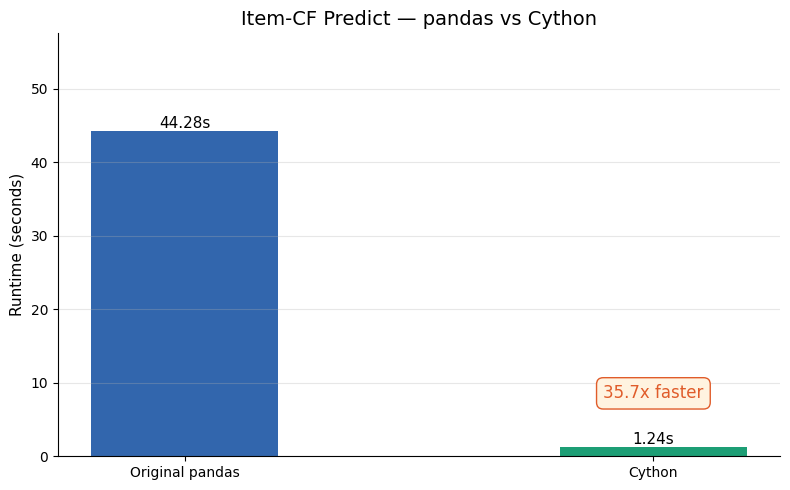

In [ ]:
# ── Re-measure both runtimes for fair comparison ─────────────────────
import matplotlib.pyplot as plt
import time

# Original pandas — re-run on current machine state
start_original = time.perf_counter()
for row in test_df.itertuples(index=False):
    _ = predict_rating_item_based(
        row.user_id, row.movie_id,
        user_item_train, item_similarity_df
    )
end_original = time.perf_counter()
original_time = end_original - start_original

# Cython — re-run on the same machine state for fair comparison
start_cython_replay = time.perf_counter()
for row in test_df.itertuples(index=False):
    uid, mid = row.user_id, row.movie_id
    if uid not in user_id_to_idx or mid not in movie_id_to_idx:
        continue
    _ = predict_rating_cython(
        uim_array, sim_array,
        user_id_to_idx[uid], movie_id_to_idx[mid]
    )
end_cython_replay = time.perf_counter()
cython_time = end_cython_replay - start_cython_replay

speedup = original_time / cython_time

print("=" * 50)
print("SPEEDUP")
print("=" * 50)
print(f"  Original pandas Runtime : {original_time:.4f} sec")
print(f"  Cython Runtime          : {cython_time:.4f} sec")
print(f"  Cython is               : {speedup:.2f}x faster")


# ── Plot — runtime comparison ────────────────────────────────────────
methods  = ['Original pandas', 'Cython']
runtimes = [original_time, cython_time]
colors   = ['#3266ad', '#1d9e75']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, runtimes, color=colors, width=0.4)

# Value labels on top of each bar
for bar, t in zip(bars, runtimes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{t:.2f}s',
        ha='center', va='bottom', fontsize=11
    )

# Speedup callout above Cython bar
ax.annotate(
    f'{speedup:.1f}x faster',
    xy=(1, cython_time),
    xytext=(1, cython_time + original_time * 0.15),
    ha='center',
    fontsize=12,
    color='#e05c2a',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#fff3e0',
        edgecolor='#e05c2a',
        linewidth=1
    )
)

ax.set_title('Item-CF Predict — pandas vs Cython', fontsize=14)
ax.set_ylabel('Runtime (seconds)', fontsize=11)
ax.set_ylim(0, max(runtimes) * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Matrix Decomposition-SVM

# What does SVD(Singular Value Decomposition) mean and do?


1.   U — Left Singular Vectors (User Matrix)： Values represent how strongly each user relates to each latent factor
factor1(action)  factor2(romance)  factor3(scifi)
User 1:      0.9               0.1               0.7
User 2:      0.2               0.8               0.1
User 3:      0.5               0.5               0.6


2.   Σ (Sigma) — Singular Values (Importance Matrix)： Each value represents how important that latent factor is globally

3.   Vt — Right Singular Vectors (Movie Matrix)： Values represent how strongly each movie relates to each latent factor







In [ ]:
# ── 1. Normalize ──────────────────────────────────────────
user_means = user_item_matrix.mean(axis=1)
R_normalized = user_item_matrix.subtract(user_means, axis=0).fillna(0)

# ── 2. SVD ────────────────────────────────────────────────
from scipy.sparse.linalg import svds
import numpy as np

U, sigma, Vt = svds(R_normalized.values, k=50)  # k = latent factors
sigma_diag = np.diag(sigma)

# ── 3. Reconstruct ────────────────────────────────────────
predicted_normalized = np.dot(np.dot(U, sigma_diag), Vt)
predicted_ratings = predicted_normalized + user_means.values.reshape(-1, 1)

# ── 4. Clip to valid range ────────────────────────────────
predicted_ratings = np.clip(predicted_ratings, 1, 5)

# ── 5. Wrap in DataFrame ──────────────────────────────────
predicted_df = pd.DataFrame(
    predicted_ratings,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

# ── 6. Recommend ──────────────────────────────────────────
def recommend_movies_svd(user_id, predicted_df, user_item_matrix, top_n=10):
    already_rated = user_item_matrix.loc[user_id].dropna().index
    user_predictions = predicted_df.loc[user_id]

    recommendations = (user_predictions
                        .drop(already_rated)
                        .sort_values(ascending=False)
                        .head(top_n))

    # Show predicted score alongside movie name
    return recommendations.reset_index().rename(columns={
        'index': 'movie',
        user_id: 'predicted_rating'
    })

# Test
recs = recommend_movies_svd(1, predicted_df, user_item_matrix, top_n=10)
print(recs)

   movie_id  predicted_rating
0       356          4.441973
1       110          4.407713
2       480          4.338404
3       364          4.319514
4       590          4.305604
5      1250          4.300319
6      3753          4.298382
7      1387          4.294407
8      2081          4.290318
9      1272          4.287433


# SVD Implementation

In [ ]:
# Surprise needs exactly 3 columns: user, item, rating
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['user_id', 'movie_id', 'rating']], reader)

print(type(data))  # surprise.dataset.DatasetAutoFolds

<class 'surprise.dataset.DatasetAutoFolds'>


In [ ]:
trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

print(f"Train ratings: {trainset.n_ratings}")
print(f"Test ratings:  {len(testset)}")

Train ratings: 800167
Test ratings:  200042


In [ ]:
model = SVD(
    n_factors=200,   # number of latent factors
    n_epochs=20,     # training iterations
    lr_all=0.005,    # learning rate
    reg_all=0.02     # regularization
)

model.fit(trainset)
print("Training complete!")

Training complete!


#Optimize parameters in model by using optuna

In [ ]:
def objective(trial):
    params = {
        'n_factors': trial.suggest_categorical('n_factors', [25, 50, 100, 200]),
        'n_epochs':  trial.suggest_categorical('n_epochs',  [10, 20, 30]),
        'lr_all':    trial.suggest_float('lr_all',  0.001, 0.01,  log=True),
        'reg_all':   trial.suggest_float('reg_all', 0.01,  0.2,   log=True),
    }
    model = SVD(**params)
    result = cross_validate(model, data, measures=['rmse'], cv=3, verbose=False)
    return result['test_rmse'].mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)   # only 30 fits, much smarter than 405

print(f"Best RMSE:   {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-04-30 00:50:53,725] A new study created in memory with name: no-name-7194f4d9-10ea-4891-b49a-ea1a7f5bb45e
[I 2026-04-30 00:51:16,548] Trial 0 finished with value: 0.8775611452967316 and parameters: {'n_factors': 25, 'n_epochs': 30, 'lr_all': 0.003920616642052932, 'reg_all': 0.025291974968120044}. Best is trial 0 with value: 0.8775611452967316.
[I 2026-04-30 00:51:55,868] Trial 1 finished with value: 0.9056244202774465 and parameters: {'n_factors': 200, 'n_epochs': 30, 'lr_all': 0.0014191029914395548, 'reg_all': 0.02432557913184519}. Best is trial 0 with value: 0.8775611452967316.
[I 2026-04-30 00:52:17,442] Trial 2 finished with value: 0.9145801084613124 and parameters: {'n_factors': 100, 'n_epochs': 20, 'lr_all': 0.0012679157828680723, 'reg_all': 0.04198799156927452}. Best is trial 0 with value: 0.8775611452967316.
[I 2026-04-30 00:52:31,708] Trial 3 finished with value: 0.9025398205793153 and parameters: {'n_factors': 100, 'n_epochs': 10, 'lr_all': 0.004850233456527898, 'reg_

Best RMSE:   0.8721
Best params: {'n_factors': 50, 'n_epochs': 30, 'lr_all': 0.005092430662508925, 'reg_all': 0.03302355564861532}


In [ ]:
#based on beyesian optiization, we update this
best_n_factors=study.best_params['n_factors']
best_n_epochs=study.best_params['n_epochs']
best_lr_all=study.best_params['lr_all']
best_reg_all=study.best_params['reg_all']

# train withe best parameters
model = SVD(
    n_factors=best_n_factors,
    n_epochs=best_n_epochs,
    lr_all=best_lr_all,
    reg_all=best_reg_all
)

model.fit(trainset)
print("Training complete!")
print(best_n_factors)

Training complete!
50


In [ ]:
predictions = model.test(testset)
rmse = surprise_accuracy.rmse(predictions, verbose=False)
mae  = surprise_accuracy.mae(predictions,  verbose=False)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

RMSE: 0.8612
MAE:  0.6756


In [ ]:
# top n recommendation per user
def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, ratings in top_n.items():
        ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = [iid for iid, _ in ratings[:n]]
    return top_n

#build ground truth
THRESHOLD = 4
def get_relevant_items(testset, threshold=THRESHOLD):
    relevant = defaultdict(set)
    for uid, iid, true_r in testset:
        if true_r >= threshold:
            relevant[uid].add(iid)
    return relevant


In [ ]:
def precision_recall_at_k(top_n, relevant_items):
    precisions, recalls = [], []
    skipped = 0  # add this
    for uid, recommended in top_n.items():
        relevant = relevant_items.get(uid, set())
        if not relevant:
            skipped += 1  # count them
            continue
        hits = len(set(recommended) & relevant)
        precisions.append(hits / len(recommended))
        recalls.append(hits / len(relevant))

    print(f"Skipped: {skipped}")  # now you can see it
    return sum(precisions) / len(precisions), sum(recalls) / len(recalls)

In [ ]:
#evaluate ranking quality: for recall and precision, the higher the better
K = 10
top_n= get_top_n(predictions, n=K)
relevant_items = get_relevant_items(testset)
precision, recall = precision_recall_at_k(top_n, relevant_items)

print(f"\nPrecision@{K}: {precision:.4f}")
print(f"Recall@{K}:    {recall:.4f}")

Skipped: 56

Precision@10: 0.7654
Recall@10:    0.6438


# Recommendation for a specific user

In [ ]:
#recommendation for a specfic user
def recommend_for_user(user_id, model, trainset, n=10):
    # movies the user has already rated (inner ids)
    try:
        inner_uid = trainset.to_inner_uid(user_id)
    except ValueError:
        print(f"User {user_id} not in training set.")
        return []

    rated_inner = {iid for iid, _ in trainset.ur[inner_uid]}

    # predict score for every unrated movie
    predictions = []
    for inner_iid in trainset.all_items():
        if inner_iid in rated_inner:
            continue
        raw_iid = trainset.to_raw_iid(inner_iid)
        est = model.predict(user_id, raw_iid).est
        predictions.append((raw_iid, est))

    # sort and return top-n
    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions[:n]

# Example usage
user_id = df['user_id'].iloc[0]
recommendations = recommend_for_user(user_id, model, trainset, n=10)

print(f"\nTop 10 recommendations for user {user_id}:")
for rank, (movie_id, score) in enumerate(recommendations, 1):
    print(f"  {rank:2}. movie_id={movie_id}  predicted_rating={score:.2f}")


Top 10 recommendations for user 1:
   1. movie_id=318  predicted_rating=4.77
   2. movie_id=2905  predicted_rating=4.76
   3. movie_id=668  predicted_rating=4.74
   4. movie_id=3338  predicted_rating=4.73
   5. movie_id=904  predicted_rating=4.70
   6. movie_id=1250  predicted_rating=4.64
   7. movie_id=910  predicted_rating=4.64
   8. movie_id=1172  predicted_rating=4.61
   9. movie_id=1423  predicted_rating=4.60
  10. movie_id=3022  predicted_rating=4.60


# SVD++ Implementation

In [ ]:
def objective(trial):
    params = {
        'n_factors': trial.suggest_categorical('n_factors', [25, 50, 100, 200]),
        'n_epochs':  trial.suggest_categorical('n_epochs',  [10, 20, 30]),
        'lr_all':    trial.suggest_float('lr_all',  0.001, 0.01, log=True),
        'reg_all':   trial.suggest_float('reg_all', 0.01,  0.2,  log=True),
    }
    model = SVDpp(**params)
    result = cross_validate(model, data, measures=['rmse'], cv=3, verbose=False)
    return result['test_rmse'].mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print(f"Best RMSE:   {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-04-30 01:02:43,131] A new study created in memory with name: no-name-674ba54e-ff67-4206-b903-8eff5691fb0b


In [ ]:
best_params = study.best_params

model = SVDpp(
    n_factors=best_params['n_factors'],
    n_epochs=best_params['n_epochs'],
    lr_all=best_params['lr_all'],
    reg_all=best_params['reg_all']
)

model.fit(trainset)
print("SVD++ training complete!")

In [ ]:
from surprise import accuracy as surprise_accuracy

predictions = model.test(testset)
rmse = surprise_accuracy.rmse(predictions, verbose=False)
mae  = surprise_accuracy.mae(predictions,  verbose=False)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

# Recommendation metrics (reuse your exact same functions)
K = 10
top_n          = get_top_n(predictions, n=K)
relevant_items = get_relevant_items(testset)
precision, recall = precision_recall_at_k(top_n, relevant_items)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"\nPrecision@{K}: {precision:.4f}")
print(f"Recall@{K}:    {recall:.4f}")
print(f"F1@{K}:        {f1:.4f}")

# Hybrid recommendations approaches

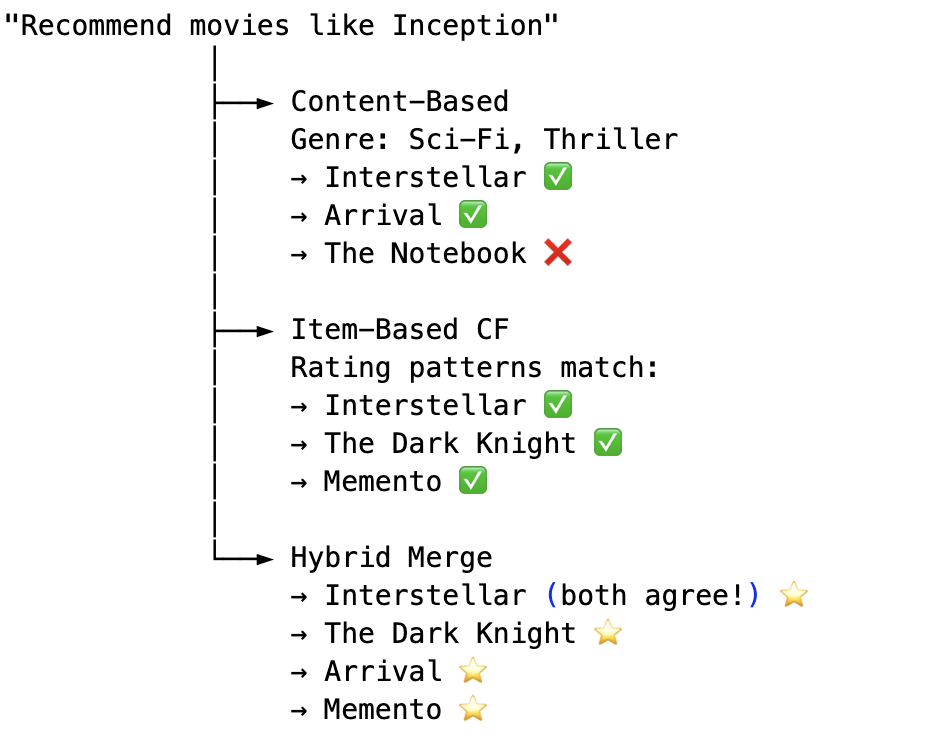

In [8]:
data

,user_id,movie_id,rating,timestamp,gender,age,occupation,zip,movieId,title,genres
0,1,1193,5,978300760,F,1,10,48067,1193,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,661,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,914,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,3408,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy
...,...,...,...,...,...,...,...,...,...,...,...
1000204,6040,1091,1,956716541,M,25,6,11106,1091,Weekend at Bernie's (1989),Comedy
1000205,6040,1094,5,956704887,M,25,6,11106,1094,"Crying Game, The (1992)",Drama|Romance|War
1000206,6040,562,5,956704746,M,25,6,11106,562,Welcome to the Dollhouse (1995),Comedy|Drama
1000207,6040,1096,4,956715648,M,25,6,11106,1096,Sophie's Choice (1982),Drama


In [9]:
# Split into views
ratings = data[['user_id', 'movie_id', 'rating', 'timestamp']]
movies  = data[['movie_id', 'title', 'genres']].drop_duplicates('movie_id')
users   = data[['user_id', 'gender', 'age', 'occupation', 'zip']].drop_duplicates('user_id')

# Clean genres column
# "Animation|Children's|Musical" → "Animation Children's Musical"
movies['genre_clean'] = movies['genres'].str.replace('|', ' ')
movies

,movie_id,title,genres,genre_clean
0,1193,One Flew Over the Cuckoo's Nest (1975),Drama,Drama
1,661,James and the Giant Peach (1996),Animation|Children's|Musical,Animation Children's Musical
2,914,My Fair Lady (1964),Musical|Romance,Musical Romance
3,3408,Erin Brockovich (2000),Drama,Drama
4,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,Animation Children's Comedy
...,...,...,...,...
919876,2198,Modulations (1998),Documentary,Documentary
940262,2703,Broken Vessels (1998),Drama,Drama
957826,2845,White Boys (1999),Drama,Drama
970914,3607,One Little Indian (1973),Comedy|Drama|Western,Comedy Drama Western


In [10]:
# ---- CONTENT BASED ----
class ContentBasedModel:
    def __init__(self, movies_df):
        self.movies = movies_df.reset_index(drop=True)
        self.indices = pd.Series(
            self.movies.index,
            index=self.movies['movie_id']
        )

        # TF-IDF on genre
        tfidf = TfidfVectorizer()
        tfidf_matrix = tfidf.fit_transform(self.movies['genre_clean'])

        # Cosine similarity matrix
        self.cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

    def get_similar_movies(self, movie_id, top_n=20):
        idx = self.indices[movie_id]
        sim_scores = list(enumerate(self.cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        sim_scores = sim_scores[1:top_n+1]  # exclude self

        movie_indices = [i[0] for i in sim_scores]
        scores       = [i[1] for i in sim_scores]

        result = self.movies[['movie_id', 'title', 'genres']].iloc[movie_indices].copy()
        result['cb_score'] = scores
        return result

# Initialize
cb_model = ContentBasedModel(movies)

In [11]:
# ---- ITEM BASED CF ----
class ItemBasedCFModel:
    def __init__(self, ratings_df):
        # Build item-user matrix
        # Rows = movies, Columns = users, Values = ratings
        self.item_user_matrix = ratings_df.pivot_table(
            index='movie_id',
            columns='user_id',
            values='rating'
        ).fillna(0)

        # Compute item-item cosine similarity
        self.item_sim = cosine_similarity(self.item_user_matrix)

        # Map movie_id to matrix index
        self.item_sim_df = pd.DataFrame(
            self.item_sim,
            index=self.item_user_matrix.index,
            columns=self.item_user_matrix.index
        )

    def get_similar_movies(self, movie_id, top_n=20):
        if movie_id not in self.item_sim_df.index:
            return pd.DataFrame()  # cold start — no ratings yet

        sim_scores = self.item_sim_df[movie_id].sort_values(ascending=False)
        sim_scores = sim_scores.iloc[1:top_n+1]  # exclude self

        result = pd.DataFrame({
            'movie_id': sim_scores.index,
            'cf_score': sim_scores.values
        })
        return result

# Initialize
cf_model = ItemBasedCFModel(ratings)

In [12]:
class HybridRecommender:
    def __init__(self, cb_model, cf_model, movies_df, ratings_df, alpha=0.5):
        self.cb      = cb_model
        self.cf      = cf_model
        self.movies  = movies_df
        self.ratings = ratings_df
        self.alpha   = alpha

    def get_user_liked_movies(self, user_id, min_rating=4):
        liked = self.ratings[
            (self.ratings['user_id'] == user_id) &
            (self.ratings['rating'] >= min_rating)
        ]['movie_id'].tolist()
        return liked

    def get_watched_movies(self, user_id):
        return self.ratings[
            self.ratings['user_id'] == user_id
        ]['movie_id'].tolist()

    def adjust_alpha(self, movie_id):
        movie_rating_count = len(
            self.ratings[self.ratings['movie_id'] == movie_id]
        )
        if movie_rating_count < 10:
            return 0.2
        else:
            return self.alpha

    def recommend(self, user_id, top_n=10):
        liked_movies = self.get_user_liked_movies(user_id)
        watched      = self.get_watched_movies(user_id)

        if not liked_movies:
            return self.fallback_popular(watched, top_n)

        all_scores = {}

        for movie_id in liked_movies:
            alpha = self.adjust_alpha(movie_id)

            cb_results = self.cb.get_similar_movies(movie_id, top_n=50)
            cf_results = self.cf.get_similar_movies(movie_id, top_n=50)

            merged = pd.merge(
                cb_results[['movie_id', 'cb_score']],
                cf_results[['movie_id', 'cf_score']],
                on='movie_id',
                how='outer'
            ).fillna(0)

            merged['hybrid_score'] = (
                (alpha * merged['cf_score']) +
                ((1 - alpha) * merged['cb_score'])
            )

            # ✅ Fixed: vectorized instead of iterrows
            scores_series = merged.set_index('movie_id')['hybrid_score']
            for mid, score in scores_series.items():
                all_scores[mid] = all_scores.get(mid, 0) + score

        result = pd.DataFrame(
            list(all_scores.items()),
            columns=['movie_id', 'hybrid_score']
        )

        result = result[~result['movie_id'].isin(watched)]
        result = result.sort_values('hybrid_score', ascending=False).head(top_n)
        result = result.merge(
            self.movies[['movie_id', 'title', 'genres']],
            on='movie_id'
        )
        return result

    def fallback_popular(self, watched, top_n):
        # ✅ Fixed: minimum rating count threshold
        counts  = self.ratings.groupby('movie_id')['rating'].count()
        means   = self.ratings.groupby('movie_id')['rating'].mean()
        popular = means[counts >= 10]

        popular = popular[~popular.index.isin(watched)]
        popular = popular.sort_values(ascending=False).head(top_n)

        result = pd.DataFrame({
            'movie_id':     popular.index,
            'hybrid_score': popular.values
        })
        return result.merge(
            self.movies[['movie_id', 'title', 'genres']],
            on='movie_id'
        )

# Initialize
hybrid = HybridRecommender(
    cb_model   = cb_model,
    cf_model   = cf_model,
    movies_df  = movies,
    ratings_df = ratings,
    alpha      = 0.5
)

In [13]:
# Get recommendations for a user
user_id = 1
recommendations = hybrid.recommend(user_id, top_n=10)
print(recommendations[['title', 'genres', 'hybrid_score']])

                              title  \
0  Shawshank Redemption, The (1994)   
1          Good Will Hunting (1997)   
2             Lion King, The (1994)   
3                    Amadeus (1984)   
4           Jungle Book, The (1967)   
5        Little Mermaid, The (1989)   
6             101 Dalmatians (1961)   
7            Charlotte's Web (1973)   
8                  Pinocchio (1940)   
9            Sleeping Beauty (1959)   

                                        genres  hybrid_score  
0                                        Drama     10.620083  
1                                        Drama      8.948081  
2                 Animation|Children's|Musical      8.924263  
3                                        Drama      8.498593  
4          Animation|Children's|Comedy|Musical      8.489248  
5  Animation|Children's|Comedy|Musical|Romance      8.407752  
6                         Animation|Children's      8.127576  
7                         Animation|Children's      8.115371  
8  

In [14]:
from sklearn.model_selection import train_test_split

# Split ratings into train and test
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,      # 80% train, 20% test
    random_state=42
)

# Rebuild models on train data only
cb_model = ContentBasedModel(movies)                          # CB uses movies only, no change
cf_model = ItemBasedCFModel(train_ratings)                    # CF trained on train only
hybrid   = HybridRecommender(cb_model, cf_model, movies, train_ratings, alpha=0.5)

In [15]:
def precision_recall_at_k(hybrid_model, test_ratings, k=10, min_rating=4, n_users=100):
    precisions = []
    recalls    = []

    # Sample users from test set
    test_users = test_ratings['user_id'].unique()[:n_users]

    for user_id in test_users:
        # Ground truth — movies user actually liked in test set
        actual = test_ratings[
            (test_ratings['user_id'] == user_id) &
            (test_ratings['rating'] >= min_rating)
        ]['movie_id'].tolist()

        if not actual:
            continue

        # Predicted — top K recommendations
        recs      = hybrid_model.recommend(user_id, top_n=k)
        predicted = recs['movie_id'].tolist()

        if not predicted:
            continue

        # How many recommended movies were actually liked?
        hits = len(set(actual) & set(predicted))

        precision = hits / k                  # out of K recommended, how many were relevant?
        recall    = hits / len(actual)        # out of all relevant, how many did we catch?

        precisions.append(precision)
        recalls.append(recall)

    avg_precision = sum(precisions) / len(precisions)
    avg_recall    = sum(recalls)    / len(recalls)

    print(f"Precision@{k}: {avg_precision:.4f}")
    print(f"Recall@{k}:    {avg_recall:.4f}")
    return avg_precision, avg_recall

# Run evaluation
precision, recall = precision_recall_at_k(hybrid, test_ratings, k=10)

Precision@10: 0.2830
Recall@10:    0.1165


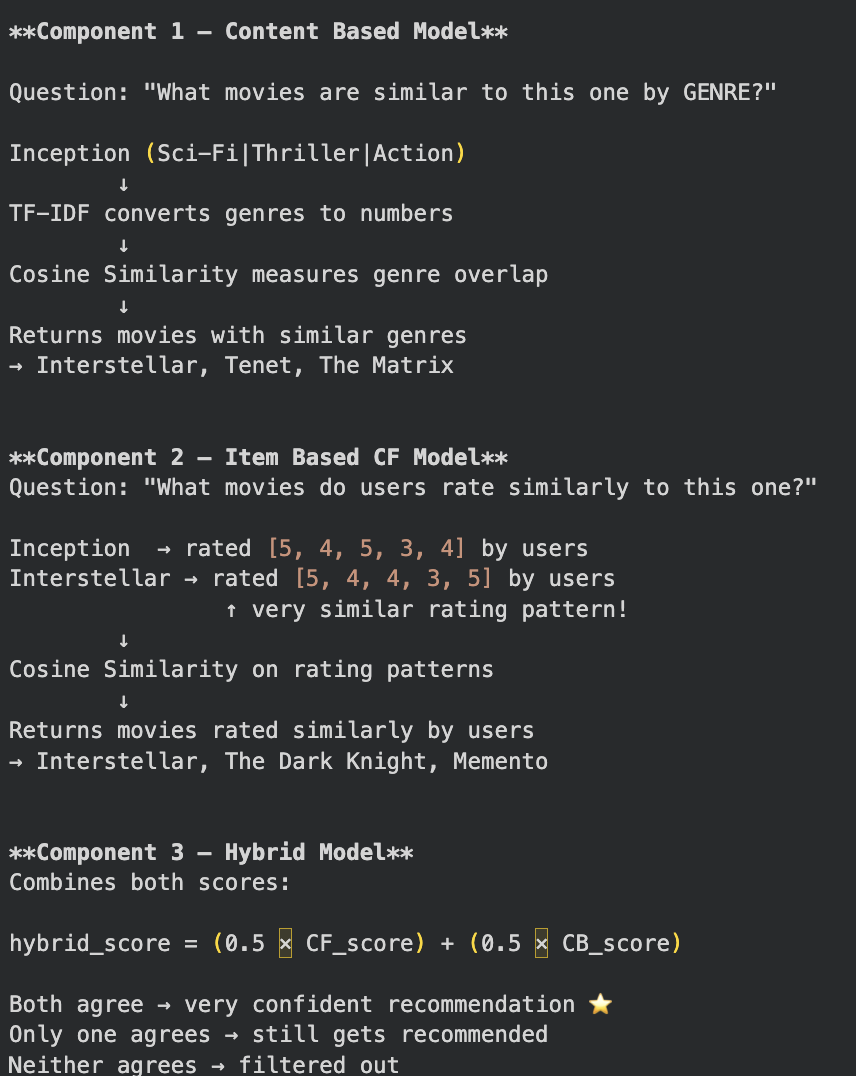